In [ ]:
import argparse
import os

# Add argument parsing
parser = argparse.ArgumentParser(description="Run contrastive learning with configurable settings.")
parser.add_argument("--batch_size", type=int, default=128, help="Batch size for training and validation.")
parser.add_argument("--gpu_id", type=str, default="0", help="GPU ID to be made visible.")
parser.add_argument("--temperature", type=float, default=0.1, help="Temperature for contrastive loss.")
parser.add_argument("--embedding_dim", type=int, default=256, help="embedding dim for contrastive loss.")
parser.add_argument("--iteration", type=int, default=1, help="Iteration value for different dataset splits.")
parser.add_argument("--hierarchy_weight", type=float, default=0.1, help="Weight for hierarchical similarity in contrastive loss.")
args, unknown = parser.parse_known_args()

# Set GPU ID
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_id

print(f"Using GPU ID: {args.gpu_id}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")

# Use the parsed batch size and temperature
batch_size = args.batch_size
temperature = args.temperature
embedding_dim = args.embedding_dim
iteration = args.iteration
hierarchy_weight = args.hierarchy_weight

print(f"Batch size: {batch_size}")
print(f"Temperature: {temperature}")
print(f"Embedding dimension: {embedding_dim}")
#print(f"Iteration: {iteration}")
print(f"Hierarchy Weight: {hierarchy_weight}")

import torch.optim.swa_utils as swa_utils

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import random
from PIL import Image
import json
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score, precision_score, recall_score, roc_curve, auc
import pandas as pd

import os
import cv2
import numpy as np
from skimage.morphology import disk, binary_dilation, binary_erosion, binary_opening, remove_small_objects
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes
from skimage.measure import label, regionprops
from skimage.measure import label as importlabel
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

from PIL import Image
from matplotlib.patches import Rectangle


import pandas as pd


Using GPU ID: 0
CUDA_VISIBLE_DEVICES: None
Batch size: 128
Temperature: 0.1
Embedding dimension: 256
Hierarchy Weight: 0.1


In [ ]:

##50 x 50


class PatchExtractor:
    def __init__(self, patch_size=50, overlap_step=25, min_coverage=0.3, non_nucleus_overlap_step=25):
        self.patch_size = patch_size
        self.overlap_step = overlap_step
        self.min_coverage = min_coverage
        self.non_nucleus_overlap_step = non_nucleus_overlap_step
        self.overlap_step_nucleus = overlap_step
        self.overlap_step_non_nucleus = non_nucleus_overlap_step

    def preprocess_image(self, image):
        """
        Preprocess the image to extract the binary mask of the nucleus.
        """
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        contrast_adjusted = clahe.apply(image)
        filtered = cv2.bilateralFilter(contrast_adjusted, d=9, sigmaColor=75, sigmaSpace=75)
        _, binary_threshold = cv2.threshold(filtered, 128, 255, cv2.THRESH_BINARY)
        filled_image = binary_fill_holes(binary_threshold > 0)
        dilated = binary_dilation(filled_image, disk(15))
        eroded = binary_erosion(dilated, disk(3))
        opened = binary_opening(eroded, disk(5))
        cleaned_mask = remove_small_objects(opened, min_size=2000).astype(np.uint8)
        return cleaned_mask

    def extract_patches(self, image_path, all_visualize=False):
        """
        Extract nucleus and non-nucleus patches from a single image and visualize/save them.
        """
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None or image.ndim != 2:
            print(f"Skipping {image_path}, not a valid grayscale image.")
            returnmasters

        # Step 1: Preprocess the image
        binary_mask = self.preprocess_image(image)

        # Step 2: Identify the largest component (nucleus)
        labeled_image = label(binary_mask)
        regions = regionprops(labeled_image)
        if not regions:
            print(f"No nucleus found in {image_path}")
            return

        # Get the largest region (nucleus)
        nucleus_region = max(regions, key=lambda r: r.area)
        y_centroid, x_centroid = map(int, nucleus_region.centroid)

        # Step 3: Extract nucleus patches (3x3 grid around centroid) with coverage check
        h, w = image.shape
        half_patch = self.patch_size // 2

        # Nucleus patches (9-grid)
        nucleus_patches = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                y_start = max(0, y_centroid + dy * self.patch_size - half_patch)
                x_start = max(0, x_centroid + dx * self.patch_size - half_patch)
                y_end = min(y_start + self.patch_size, h)
                x_end = min(x_start + self.patch_size, w)
                patch = image[y_start:y_end, x_start:x_end]
                patch_mask = binary_mask[y_start:y_end, x_start:x_end]
                coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
                nucleus_patches.append(((x_start, y_start, x_end, y_end), patch, coverage))

        # Overlapping nucleus patches
        overlapping_patches = []
        for (x_start, y_start, x_end, y_end), _, _ in nucleus_patches:
            for oy in range(y_start, y_end - self.overlap_step_nucleus + 1, self.overlap_step_nucleus):
                for ox in range(x_start, x_end - self.overlap_step_nucleus + 1, self.overlap_step_nucleus):
                    sub_x_end = min(ox + self.patch_size, x_end)
                    sub_y_end = min(oy + self.patch_size, y_end)
                    patch = image[oy:sub_y_end, ox:sub_x_end]
                    patch_mask = binary_mask[oy:sub_y_end, ox:sub_x_end]
                    coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
                    if coverage >= self.min_coverage:
                        overlapping_patches.append(((ox, oy, sub_x_end, sub_y_end), patch, coverage))

        # Non-nucleus patches
        non_nucleus_patches = []
        for y in range(0, h - self.patch_size + 1, self.patch_size):
            for x in range(0, w - self.patch_size + 1, self.patch_size):
                if any(
                    x_start < x + self.patch_size and x < x_end and y_start < y + self.patch_size and y < y_end
                    for (x_start, y_start, x_end, y_end), _, _ in nucleus_patches
                ):
                    continue
                patch = image[y:y + self.patch_size, x:x + self.patch_size]
                patch_mask = binary_mask[y:y + self.patch_size, x:x + self.patch_size]
                coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
                if coverage >= self.min_coverage:
                    non_nucleus_patches.append(((x, y), patch, coverage))

        # Overlapping non-nucleus patches
        overlapping_non_nucleus_patches = []
        for y in range(0, h - self.patch_size + 1, self.overlap_step_non_nucleus):
            for x in range(0, w - self.patch_size + 1, self.overlap_step_non_nucleus):
                if any(
                    x_start < x + self.patch_size and x < x_end and y_start < y + self.patch_size and y < y_end
                    for (x_start, y_start, x_end, y_end), _, _ in nucleus_patches
                ):
                    continue
                patch = image[y:y + self.patch_size, x:x + self.patch_size]
                patch_mask = binary_mask[y:y + self.patch_size, x:x + self.patch_size]
                coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
                if coverage >= self.min_coverage:
                    overlapping_non_nucleus_patches.append(((x, y), patch, coverage))





        # Step 7: Visualize or Save Results
        if all_visualize:
            self.visualize_patches(image, binary_mask, nucleus_patches, overlapping_patches, non_nucleus_patches, overlapping_non_nucleus_patches)

        return overlapping_patches, overlapping_non_nucleus_patches

    def visualize_patches(self, image, binary_mask, nucleus_patches, overlapping_nucleus_patches, non_nucleus_patches, overlapping_non_nucleus_patches):
        """
        Visualize all patches and overlay them on the original image.
        """

        # Display original image
        plt.figure(figsize=(8, 8))
        plt.title("Original Image")
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()

        # Display binary mask
        plt.figure(figsize=(8, 8))
        plt.title("Binary Mask")
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')
        plt.show()

        def draw_patches(image, patches, color, title, is_non_nucleus=False):
            """
            Draw rectangles for given patches on the image.
            """
            overlay_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

            count_50x50 = 0  # Counter for patches with size (50, 50)
            count_other = 0  # Counter for patches with other sizes

            for patch_data in patches:
                if is_non_nucleus:  # Non-nucleus patches have (x, y) format
                    (x, y),patch, _ = patch_data
                    x_end, y_end = x + self.patch_size, y + self.patch_size
                else:  # Nucleus patches have (x_start, y_start, x_end, y_end) format
                    (x, y, x_end, y_end), patch, _ = patch_data

                # Count patches based on their shape
                if patch.shape == (50, 50):
                    count_50x50 += 1
                else:
                    count_other += 1

                cv2.rectangle(overlay_image, (x, y), (x_end, y_end), color, 2)

            # Print summary counts instead of all patch sizes
            print(f"{title}: 50x50 Patches = {count_50x50}, Different Size Patches = {count_other}")

            plt.figure(figsize=(8, 8))
            plt.title(title)
            plt.imshow(cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

        # Visualize all patches using the same function
        draw_patches(image, nucleus_patches, (255, 0, 0), "Nucleus Patches (Red)")
        draw_patches(image, overlapping_nucleus_patches, (0, 255, 0), "Overlapping Nucleus Patches (Green)")
        draw_patches(image, non_nucleus_patches, (0, 0, 255), "Non-Nucleus Patches (Blue)", is_non_nucleus=True)
        draw_patches(image, overlapping_non_nucleus_patches, (255, 255, 0), "Overlapping Non-Nucleus Patches (Yellow)", is_non_nucleus=True)

In [ ]:
# #25 x 50

# class PatchExtractor:
#     def __init__(self, patch_size=50, overlap_step=25, min_coverage=0.3, non_nucleus_overlap_step=25):
#         self.patch_size = patch_size
#         self.overlap_step = overlap_step
#         self.min_coverage = min_coverage
#         self.non_nucleus_overlap_step = non_nucleus_overlap_step

#     def preprocess_image(self, image):
#         """
#         Preprocess the image to extract the binary mask of the nucleus.
#         """
#         clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#         contrast_adjusted = clahe.apply(image)
#         filtered = cv2.bilateralFilter(contrast_adjusted, d=9, sigmaColor=75, sigmaSpace=75)
#         _, binary_threshold = cv2.threshold(filtered, 128, 255, cv2.THRESH_BINARY)
#         filled_image = binary_fill_holes(binary_threshold > 0)
#         dilated = binary_dilation(filled_image, disk(15))
#         eroded = binary_erosion(dilated, disk(3))
#         opened = binary_opening(eroded, disk(5))
#         cleaned_mask = remove_small_objects(opened, min_size=2000).astype(np.uint8)
#         return cleaned_mask

#     def extract_patches(self, image_path, nucleus_dir=None, non_nucleus_dir=None, all_visualize=False):
#         """
#         Extract nucleus and non-nucleus patches from a single image and visualize/save them.
#         """
#         image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#         if image is None or image.ndim != 2:
#             print(f"Skipping {image_path}, not a valid grayscale image.")
#             return

#         # Step 1: Preprocess the image
#         binary_mask = self.preprocess_image(image)

#         # Step 2: Identify the largest component (nucleus)
#         labeled_image = label(binary_mask)
#         regions = regionprops(labeled_image)
#         if not regions:
#             print(f"No nucleus found in {image_path}")
#             return

#         # Get the largest region (nucleus)
#         nucleus_region = max(regions, key=lambda r: r.area)
#         y_centroid, x_centroid = map(int, nucleus_region.centroid)

#         # Step 3: Extract nucleus patches (3x3 grid around centroid) with coverage check
#         h, w = image.shape
#         half_patch = self.patch_size // 2
#         nucleus_patches = []

#         for dy in [-1, 0, 1]:
#             for dx in [-1, 0, 1]:
#                 y_start = max(0, y_centroid + dy * self.patch_size - half_patch)
#                 x_start = max(0, x_centroid + dx * self.patch_size - half_patch)
#                 y_end = min(y_start + self.patch_size, h)
#                 x_end = min(x_start + self.patch_size, w)
#                 patch = image[y_start:y_end, x_start:x_end]
#                 patch_mask = binary_mask[y_start:y_end, x_start:x_end]
#                 coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
#                 nucleus_patches.append(((x_start, y_start, x_end, y_end), patch, coverage))

#         # Step 4: Extract overlapping nucleus patches strictly within the 9-grid
#         overlapping_patches = []
#         for (x_start, y_start, x_end, y_end), _, _ in nucleus_patches:
#             for oy in range(y_start, y_end - self.overlap_step + 1, self.overlap_step):
#                 for ox in range(x_start, x_end - self.overlap_step + 1, self.overlap_step):
#                     sub_x_end = min(ox + self.patch_size, x_end)
#                     sub_y_end = min(oy + self.patch_size, y_end)
#                     patch = image[oy:sub_y_end, ox:sub_x_end]
#                     patch_mask = binary_mask[oy:sub_y_end, ox:sub_x_end]
#                     coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
#                     if coverage >= self.min_coverage:
#                         overlapping_patches.append(((ox, oy, sub_x_end, sub_y_end), patch, coverage))

#         # Step 5: Extract non-nucleus patches
#         non_nucleus_patches = []
#         for y in range(0, h - self.patch_size + 1, self.patch_size):
#             for x in range(0, w - self.patch_size + 1, self.patch_size):
#                 # Ensure non-nucleus patches do not overlap or touch any part of the 9-grid nucleus patches
#                 if any(
#                     x_start < x + self.patch_size and x < x_end and y_start < y + self.patch_size and y < y_end
#                     for (x_start, y_start, x_end, y_end), _, _ in nucleus_patches
#                 ):
#                     continue
#                 patch = image[y:y + self.patch_size, x:x + self.patch_size]
#                 patch_mask = binary_mask[y:y + self.patch_size, x:x + self.patch_size]
#                 coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
#                 if coverage >= self.min_coverage:
#                     non_nucleus_patches.append(((x, y), patch, coverage))

#         # Step 6: Extract overlapping non-nucleus patches
#         overlapping_non_nucleus_patches = []
#         for (x, y), _, _ in non_nucleus_patches:
#             for oy in range(y, y + self.patch_size - self.non_nucleus_overlap_step + 1, self.non_nucleus_overlap_step):
#                 for ox in range(x, x + self.patch_size - self.non_nucleus_overlap_step + 1, self.non_nucleus_overlap_step):
#                     sub_x_end = min(ox + self.patch_size, x + self.patch_size)
#                     sub_y_end = min(oy + self.patch_size, y + self.patch_size)
#                     patch = image[oy:sub_y_end, ox:sub_x_end]
#                     patch_mask = binary_mask[oy:sub_y_end, ox:sub_x_end]
#                     coverage = np.sum(patch_mask) / (self.patch_size * self.patch_size)
#                     if coverage >= self.min_coverage:
#                         overlapping_non_nucleus_patches.append(((ox, oy, sub_x_end, sub_y_end), patch, coverage))




#         # Step 7: Visualize or Save Results
#         if all_visualize:
#             self.visualize_patches(image, binary_mask, nucleus_patches, overlapping_patches, non_nucleus_patches, overlapping_non_nucleus_patches)

#         return overlapping_patches, overlapping_non_nucleus_patches

#     def visualize_patches(self, image, binary_mask, nucleus_patches, overlapping_patches, non_nucleus_patches, overlapping_non_nucleus_patches):
#         """
#         Visualize nucleus and non-nucleus patches and overlay them on the original image.
#         """
#         # Display binary mask
#         plt.figure(figsize=(8, 8))
#         plt.title("Binary Mask")
#         plt.imshow(binary_mask, cmap='gray')
#         plt.axis('off')
#         plt.show()

#         # Nucleus 9-grid patches visualization with coverage annotation
#         overlay_image_9grid = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
#         for (x_start, y_start, x_end, y_end), _, coverage in nucleus_patches:
#             color = (255, 0, 0)  # Blue for nucleus grid
#             cv2.rectangle(overlay_image_9grid, (x_start, y_start), (x_end, y_end), color, 2)
#             if coverage < self.min_coverage:
#                 cv2.putText(overlay_image_9grid, "Excluded", (x_start, y_start - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
#         plt.figure(figsize=(8, 8))
#         plt.title("Nucleus 9-Grid Patches (Blue)")
#         plt.imshow(cv2.cvtColor(overlay_image_9grid, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.show()

#         # Overlapping nucleus patches visualization
#         overlay_image_overlapping = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
#         for (x_start, y_start, x_end, y_end), _, _ in overlapping_patches:
#             cv2.rectangle(overlay_image_overlapping, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
#         plt.figure(figsize=(8, 8))
#         plt.title("Overlapping Nucleus Patches (Green)")
#         plt.imshow(cv2.cvtColor(overlay_image_overlapping, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.show()

#         # Non-nucleus patches visualization
#         overlay_image_non_nucleus = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
#         for (x, y), _, _ in non_nucleus_patches:
#             cv2.rectangle(overlay_image_non_nucleus, (x, y), (x + self.patch_size, y + self.patch_size), (0, 0, 255), 2)
#         plt.figure(figsize=(8, 8))
#         plt.title("Non-Nucleus Patches (Red)")
#         plt.imshow(cv2.cvtColor(overlay_image_non_nucleus, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.show()

#         # Overlapping non-nucleus patches visualization
#         overlay_image_overlapping_non_nucleus = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
#         for (x_start, y_start, x_end, y_end), _, _ in overlapping_non_nucleus_patches:
#             cv2.rectangle(overlay_image_overlapping_non_nucleus, (x_start, y_start), (x_end, y_end), (255, 255, 0), 2)
#         plt.figure(figsize=(8, 8))
#         plt.title("Overlapping Non-Nucleus Patches (Yellow)")
#         plt.imshow(cv2.cvtColor(overlay_image_overlapping_non_nucleus, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.show()

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import random

class ImageDataset(Dataset):
    def __init__(self, folder_path, patch_extractor, transform=None, model=None, device=None, visualize=False):
        """
        Args:
            folder_path: Path to the root directory containing 'control' and 'stress' subdirectories.
            patch_extractor: Instance of the PatchExtractor class.
            transform: PyTorch transform for preprocessing patches.
            model: Trained model to predict patch scores.
            device: Device for model inference.
            visualize: Whether to visualize top 10 patches on the original image.
        """
        self.folder_path = folder_path
        self.patch_extractor = patch_extractor
        self.transform = transform
        self.model = model
        self.device = device
        self.visualize = visualize

        self.image_files = []
        self.labels = []

        # **First loop: Process images in the `control` and `stress` subdirectories**
        for sub_dir in ["control", "stress"]:
            full_path = os.path.join(folder_path, sub_dir)
            if not os.path.exists(full_path):
                print(f"Warning: {full_path} does not exist. Skipping.")
                continue
            for file in os.listdir(full_path):
                if file.endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(full_path, file)
                    try:
                        nucleus_patches, non_nucleus_patches = self.patch_extractor.extract_patches(img_path)

                        if len(nucleus_patches) < 10:
                            print(f"Skipping {img_path} - Not enough nucleus patches ({len(nucleus_patches)})")
                            continue

                        if len(non_nucleus_patches) == 0:
                            print(f"Skipping {img_path} - No non-nucleus patches found")
                            continue  # Skip only if **zero** non-nucleus patches

                        # **Do not skip images with non-nucleus patches < 10 (handle in __getitem__)**
                        self.image_files.append(img_path)
                        real_label = 0 if "control" in sub_dir.lower() else 1
                        self.labels.append(real_label)

                    except Exception as e:
                        print(f"Error processing {img_path}: {e}")

        # **Second loop: Process images directly in the root directory (unknown labels)**
        for file in os.listdir(folder_path):
            full_path = os.path.join(folder_path, file)
            if os.path.isfile(full_path) and file.lower().endswith(('.png', '.jpg', '.jpeg')) and \
               not any(folder in full_path for folder in ["control", "stress"]):
                try:
                    nucleus_patches, non_nucleus_patches = self.patch_extractor.extract_patches(full_path)

                    if len(nucleus_patches) < 10:
                        print(f"Skipping {full_path} - Not enough nucleus patches ({len(nucleus_patches)})")
                        continue

                    if len(non_nucleus_patches) == 0:
                        print(f"Skipping {full_path} - No non-nucleus patches found")
                        continue  # Skip only if **zero** non-nucleus patches

                    # **Do not skip images with non-nucleus patches < 10 (handle in __getitem__)**
                    self.image_files.append(full_path)
                    self.labels.append(2)  # Unknown label

                except Exception as e:
                    print(f"Error processing {full_path}: {e}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        try:
            img_path = self.image_files[idx]
            true_label = self.labels[idx]
            image_name = os.path.basename(img_path)  # Extract image name

            # Extract patches using the PatchExtractor
            nucleus_patches, non_nucleus_patches = self.patch_extractor.extract_patches(img_path)

            if len(nucleus_patches) < 10:
                print(f"Skipping image at index {idx} due to insufficient nucleus patches.")
                return None

            # **🔹 If non-nucleus patches < 10, duplicate random ones to make 10**
            if 0 < len(non_nucleus_patches) < 10:
                print(f"Image {img_path}: Non-nucleus patches ({len(non_nucleus_patches)}) < 10, duplicating...")
                while len(non_nucleus_patches) < 10:
                    non_nucleus_patches.append(random.choice(non_nucleus_patches))

            # Predict scores for nucleus patches
            nucleus_predictions = []
            for (x_start, y_start, x_end, y_end), patch, _ in nucleus_patches:
                patch_tensor = self.transform(Image.fromarray(patch)).unsqueeze(0).to(self.device)
                prediction = self.model(patch_tensor).item()
                nucleus_predictions.append(((x_start, y_start, x_end, y_end), patch_tensor, prediction))

            # # Predict scores for non-nucleus patches for 25 x 50
            # non_nucleus_predictions = []
            # for (x_start, y_start, x_end, y_end), patch, _ in non_nucleus_patches:
            #     patch_tensor = self.transform(Image.fromarray(patch)).unsqueeze(0).to(self.device)
            #     prediction = self.model(patch_tensor).item()
            #     non_nucleus_predictions.append(((x_start, y_start, x_end, y_end), patch_tensor, prediction))


            # Predict scores for non-nucleus patches for 50 x 50
            non_nucleus_predictions = []
            for (x, y), patch, _ in non_nucleus_patches:
                patch_tensor = self.transform(Image.fromarray(patch)).unsqueeze(0).to(self.device)
                prediction = self.model(patch_tensor).item()
                non_nucleus_predictions.append(((x, y), patch_tensor, prediction))

            # Sort and select top 10 nucleus and non-nucleus patches
            top_nucleus = sorted(nucleus_predictions, key=lambda x: x[2], reverse=True)[:10]
            top_non_nucleus = sorted(non_nucleus_predictions, key=lambda x: x[2], reverse=True)[:10]

            # Combine tensors for top patches
            top_nucleus_tensors = torch.cat([x[1] for x in top_nucleus], dim=0)
            top_non_nucleus_tensors = torch.cat([x[1] for x in top_non_nucleus], dim=0)

            # Extract the corresponding locations **from the sorted patches**
            top_nucleus_locations = [x[0] for x in top_nucleus]
            top_non_nucleus_locations = [x[0] for x in top_non_nucleus]

            return {
            "image_idx": idx,
            "image_name": image_name,  # Add image name to result
            "nucleus_patches": top_nucleus_tensors,
            "nucleus_probs": [x[2] for x in top_nucleus],
            "non_nucleus_patches": top_non_nucleus_tensors,
            "non_nucleus_probs": [x[2] for x in top_non_nucleus],
            "true_label": true_label,
            "nucleus_locations": top_nucleus_locations,  # Sorted locations
            "non_nucleus_locations": top_non_nucleus_locations  # Sorted locations
        }
        except Exception as e:
            print(f"Error processing image at index {idx}: {e}")
            return None

    @staticmethod
    def visualize_top_patches(image, patches, title, color="blue"):
        """
        Visualize the top patches by overlaying their bounding boxes on the image.
        """
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(image, cmap='gray')
        for (x_start, y_start, x_end, y_end), _, _ in patches:
            rect = Rectangle((x_start, y_start), x_end - x_start, y_end - y_start,
                             linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
        ax.set_title(title)
        plt.axis('off')
        plt.show()


In [ ]:
def visualization():
    for i in range (top(x) in patches):
        ax.imshow(image, cmap='gray')
        for folder in folders:
            folder_path = os.path.join(base_dir, folder)

            size_count = defaultdict(int)

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

        if file.lower().endswith((".png", ".jpg", ".jpeg", ".tif")):
            img = cv2.imread(file_path)

            if img is None:
                continue

            h, w = img.shape[:2]
            size_count[(h, w)] += 1


            self.cross_attention_nucleus = CrossAttention(embed_dim)  # Nucleus -> Non-Nucleus
            self.cross_attention_non_nucleus = CrossAttention(embed_dim)  # Non-Nucleus -> Nucleus


            self.cross_attention = CrossAttention(cloc)

            nucleus_patches = nucleus_patches.view(B * N, C, H, W)
            non_nucleus_patches = non_nucleus_patches.view(B * M, C, H, W)


            if len(loc) >= 4:
                x1, y1 = int(loc[0]), int(loc[1])
            else:
                x, y = int(loc[0]), int(loc[1])
                x1, y1 = max(0, x - 25), max(0, y - 25)

            x2, y2 = min(W, x1 + 50), min(H, y1 + 50)
            if (x2 - x1 == 50) and (y2 - y1 == 50):
                return x1, y1, x2, y2

            self.encoder = encoder
            self.mlp_head = mlp_head
            self.fc = nn.Linear(embedding_dim, 1)  # Fully connected layer for binary classification
            self.sigmoid = nn.Sigmoid()


            for i, stressor in enumerate(stressors):
                for j, metric in enumerate(metrics):
                    ax = axes[i, j]
                    subset = df[(df['Stressor'] == stressor) & (df['Metric'] == metric)]

                    # Violin
                    sns.violinplot(data=subset, x='Model', y='Score', hue='Model',
                           order=models_order, palette=custom_palette,
                           ax=ax, inner=None, linewidth=1, dodge=False)

                    # Individual Points
                    sns.stripplot(data=subset, x='Model', y='Score', hue='Model',
                          order=models_order, palette=custom_palette,
                          ax=ax, jitter=True, size=4, edgecolor='black', linewidth=0.5, dodge=False, legend=False)

                    # Formatting
                    if i == 0: ax.set_title(metric, fontweight='bold', fontsize=14)
                    if j == 0: ax.set_ylabel(f"{stressor}", fontweight='bold', fontsize=12)
                    else: ax.set_ylabel("")

                    ax.set_xlabel("")
                    if i < 2:
                        ax.set_xticklabels([])
                    else:
                        ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=10)

                    # Legend cleanup inside subplots
                    if ax.get_legend(): ax.get_legend().remove()

            for metric in metrics:
                for stressor in stressors:
                    for model in models_order:
                        mean, std = stats_dict[metric][stressor][model]
                        points = np.random.normal(mean, std, 10) # 10 runs
                        points = np.clip(points, 0.0, 1.0)
                        for point in points:
                            simulated_data.append({
                            'Model': model,
                            'Stressor': stressor,
                            'Metric': metric,
                            'Score': point
                            })


            nuc_boxes = {}
            for i, loc in enumerate(nucleus_locations):
                box = loc_to_box_50(loc, H, W)
                if box is not None:
                    nuc_boxes[i] = box

            cyto_boxes = {}
            for i, loc in enumerate(non_nucleus_locations):
                box = loc_to_box_50(loc, H, W)
                if box is not None:
                    cyto_boxes[i] = box



In [ ]:
def collate_skip_none(batch):
    """
    Filters out None items returned by Dataset.__getitem__.
    Returns None if the whole batch is invalid.
    """
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None

    # use default collate on the remaining dicts
    from torch.utils.data._utils.collate import default_collate
    return default_collate(batch)

In [ ]:
def create_dataloader(folder_path, patch_extractor, transform, model, device, batch_size=1, visualize=False):
    """
    Create a DataLoader for a given dataset.

    Args:
        folder_path: Path to the dataset directory.
        patch_extractor: Instance of the PatchExtractor class.
        transform: PyTorch transform for preprocessing patches.
        model: Trained model to predict patch scores.
        device: Device for model inference.
        batch_size: Batch size for the DataLoader.
        visualize: Whether to visualize patches.

    Returns:
        DataLoader object.
    """
    dataset = ImageDataset(
        folder_path=folder_path,
        patch_extractor=patch_extractor,
        transform=transform,
        model=model,
        device=device,
        visualize=visualize
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_skip_none  # ✅ IMPORTANT
    )

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_channels=1, embedding_dim=embedding_dim):
        super(Encoder, self).__init__()
        layers = []
        channels = [input_channels, 32, 64, 128, 256][:int(np.log2(embedding_dim / 32)) + 2]
        for i in range(len(channels) - 1):
            layers.append(nn.Conv2d(channels[i], channels[i + 1], kernel_size=3, stride=1, padding=1))
            layers.append(nn.ReLU(inplace=False))
            if i != len(channels) - 2:  # No pooling in the last layer
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.network = nn.Sequential(*layers)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.network(x)
        x = self.avg_pool(x)
        return x.view(x.size(0), -1)

In [ ]:
class MLPProjection(nn.Module):
    def __init__(self, input_dim=embedding_dim, hidden_dim=embedding_dim, output_dim=embedding_dim):
        """
        Builds an MLP projection model with two linear layers.
        Args:
            input_dim: Dimension of the input vector (default is 128).
            hidden_dim: Number of nodes in the hidden layer (default is 128).
            output_dim: Dimension of the output vector (default is 128).
        """
        super(MLPProjection, self).__init__()

        # First linear layer with hidden_dim nodes
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc1_act = nn.ReLU(inplace=False)

        # Second linear layer with output_dim nodes
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Apply first linear layer with ReLU activation
        x = self.fc1_act(self.fc1(x))

        # Apply second linear layer
        x = self.fc2(x)
        return x

In [ ]:
class BinaryClassifier(nn.Module):
    def __init__(self, encoder, mlp_head, embedding_dim=embedding_dim):
        """
        A binary classifier model that uses a frozen encoder and MLP head for embeddings.
        Args:
            encoder: The frozen encoder model.
            mlp_head: The frozen MLP head model.
            embedding_dim: The dimension of the MLP head's output embeddings.
        """
        super(BinaryClassifier, self).__init__()

#         # Freeze the encoder parameters
#         for param in encoder.parameters():
#             param.requires_grad = False

#         # Freeze the MLP head parameters
#         for param in mlp_head.parameters():
#             param.requires_grad = False

        self.encoder = encoder
        self.mlp_head = mlp_head
        self.fc = nn.Linear(embedding_dim, 1)  # Fully connected layer for binary classification
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for binary output

    def forward(self, x):
        # with torch.no_grad():  # Ensure encoder and MLP head are not updated
        features = self.encoder(x)  # Extract features using the frozen encoder
        embeddings = self.mlp_head(features)  # Get embeddings from the MLP head
        embeddings = F.normalize(embeddings)

        logits = self.fc(embeddings)  # Pass embeddings through the fully connected layer
        output = self.sigmoid(logits)  # Apply sigmoid to get probabilities
        return output

In [ ]:
# Initialize PatchExtractor and transformations
patch_extractor = PatchExtractor(patch_size=50)
transform = transforms.Compose([
    transforms.Resize((50, 50)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(input_channels=1).to(device)
mlp_head = MLPProjection(input_dim=embedding_dim, hidden_dim=embedding_dim, output_dim=embedding_dim).to(device)

binary_model = BinaryClassifier(encoder, mlp_head, embedding_dim=embedding_dim).to(device)

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, embed_dim):
        super(CrossAttention, self).__init__()
        self.Wq = nn.Linear(embed_dim, embed_dim)
        self.Wk = nn.Linear(embed_dim, embed_dim)
        self.Wv = nn.Linear(embed_dim, embed_dim)
        self.scaling_factor = embed_dim ** 0.5
        # Learnable parameter, initially set to 0.0 (sigmoid(0) = 0.5)
        #self.raw_lambda_param = nn.Parameter(torch.tensor(0.0))

    def forward(self, queries, keys, values):
        Q = self.Wq(queries)  # (B, N, D)
        K = self.Wk(keys)    # (B, M, D)
        V = self.Wv(values)  # (B, M, D)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-1, -2)) / self.scaling_factor   # (B, N, M)
        weights = F.softmax(scores, dim=-1)  # (B, N, M)

        # Attention output
        attention_output = torch.matmul(weights, V)  # (B, N, D)


        # Apply sigmoid to map raw_lambda_param to [0, 1]
        #lambda_param = torch.sigmoid(self.raw_lambda_param)

        # Refined features: X' = X + \lambda * Attention(X, Y)
        #refined_queries = queries + lambda_param * attention_output
        return attention_output, weights




class BinaryPredictionHead(nn.Module):
    def __init__(self, input_dim):
        super(BinaryPredictionHead, self).__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Input `x` is the concatenated scores of nucleus and non-nucleus patches
        return torch.sigmoid(self.fc(x))


class CrossAttentionModel(nn.Module):
    def __init__(self, encoder, mlp_head, embed_dim=embedding_dim):
        super(CrossAttentionModel, self).__init__()

        # Frozen encoder
        self.encoder = encoder
        self.mlp_head = mlp_head
#         for param in self.encoder.parameters():
#             param.requires_grad = True

#         # Freeze the MLP head parameters
#         for param in mlp_head.parameters():
#             param.requires_grad = True

        self.cross_attention_nucleus = CrossAttention(embed_dim)  # Nucleus -> Non-Nucleus
        self.cross_attention_non_nucleus = CrossAttention(embed_dim)  # Non-Nucleus -> Nucleus

        # Raw learnable parameter for alpha
        # self.raw_alpha1 = nn.Parameter(torch.tensor(0.0))
        # self.raw_alpha2 = nn.Parameter(torch.tensor(0.0))
        # self.raw_alpha3 = nn.Parameter(torch.tensor(0.0))
        self.raw_alpha = nn.Parameter(torch.tensor(0.0))# Initial value corresponds to sigmoid(0) = 0.5

        # Linear layer for patch-wise projection
        self.patch_linear = nn.Linear(embed_dim, 1)

        # Binary prediction head
        self.binary_head = BinaryPredictionHead(20)

    def forward(self, nucleus_patches, non_nucleus_patches):
        # Encode patches
        B, N, C, H, W = nucleus_patches.shape  # Batch size, number of nucleus patches
        _, M, _, _, _ = non_nucleus_patches.shape  # Number of non-nucleus patches

        # Reshape patches into batches
        nucleus_patches = nucleus_patches.view(B * N, C, H, W)
        non_nucleus_patches = non_nucleus_patches.view(B * M, C, H, W)

        # with torch.no_grad():
        nucleus_embeddings_features = self.encoder(nucleus_patches)  # (B * N, D)
        non_nucleus_embeddings_features = self.encoder(non_nucleus_patches)  # (B * M, D)
        nucleus_embeddings = self.mlp_head(nucleus_embeddings_features)  # (B * N, D)
        non_nucleus_embeddings = self.mlp_head(non_nucleus_embeddings_features)  # (B * M, D)
        nucleus_embeddings = F.normalize(nucleus_embeddings)
        non_nucleus_embeddings = F.normalize(non_nucleus_embeddings)

        # Reshape back to batch with patches
        nucleus_proj = nucleus_embeddings.view(B, N, -1)  # (B, N, D)
        non_nucleus_proj = non_nucleus_embeddings.view(B, M, -1)  # (B, M, D)

        # Cross-attention: Nucleus -> Non-Nucleus
        attention_nucleus, nc_weights = self.cross_attention_nucleus(
            nucleus_proj, non_nucleus_proj, nucleus_proj
        )  # (B, N, D)

        # Cross-attention: Non-Nucleus -> Nucleus
        attention_non_nucleus, cn_weights = self.cross_attention_non_nucleus(
            non_nucleus_proj, nucleus_proj, non_nucleus_proj
        )  # (B, M, D)

        # Process raw_alpha through sigmoid to ensure it is in [0, 1]
        alpha = torch.sigmoid(self.raw_alpha)

        refined_nucleus = nucleus_proj + alpha * attention_nucleus
        refined_non_nucleus = non_nucleus_proj + (1 - alpha) * attention_non_nucleus

        # Stack refined nucleus and non-nucleus features along the patch dimension
        combined_features = torch.cat([refined_nucleus, refined_non_nucleus], dim=1)  # (B, 20, D)

        # Pass through linear layer for each patch
        patch_scores = self.patch_linear(combined_features)  # (B, 20, 1)

        # Squeeze to shape (B, 20)
        patch_scores = patch_scores.squeeze(-1)  # (B, 20)

        # Binary classification
        output = self.binary_head(patch_scores)

        return output, attention_nucleus, attention_non_nucleus, nc_weights, cn_weights, alpha

In [ ]:
cross_attention_model = CrossAttentionModel(encoder, mlp_head,  embed_dim=embedding_dim).to(device)

In [ ]:
cross_attention_model.eval()

CrossAttentionModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU()
    )
    (avg_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (mlp_head): MLPProjection(
    (fc1): Linear(in_features=256, out_features=256, bias=True)
    (fc1_act): ReLU()
    (fc2): Linear(in_features=256, out_features=256, bias=True)
  )
  (cross_attention_nucleus): CrossAttentio

In [ ]:
extra_val_loader = create_dataloader(

    folder_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/",

    patch_extractor=patch_extractor,

    transform=transform,

    model=binary_model,

    device=device,

    batch_size=1,

    visualize=False  # Set to True for visualization during validation

)

In [ ]:
image7_val_loader = create_dataloader(

    folder_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/checking/",

    patch_extractor=patch_extractor,

    transform=transform,

    model=binary_model,

    device=device,

    batch_size=1,

    visualize=False  # Set to True for visualization during validation

)

In [ ]:


# import torch
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# import scipy.ndimage

# # Load the original image in grayscale
# image_path = "/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/stress/193_RI.jpg"
# original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# if original_image is None:
#     raise ValueError(f"Error: Unable to load image from {image_path}")


# def compute_alpha_and_pred_from_cross_attention(batch, model, device, show_heatmap=True):
#     """
#     Uses CrossAttentionModel forward() to get nc_weights and cn_weights,
#     builds combined KxK interaction map, computes 1xK vectors and alpha,
#     and returns final prediction score as well.
#     """
#     model.eval()

#     nucleus_patches = batch["nucleus_patches"].to(device)       # (B,K,1,H,W)
#     non_nucleus_patches = batch["non_nucleus_patches"].to(device)  # (B,K,1,H,W)

#     with torch.no_grad():
#         # IMPORTANT: this calls your CrossAttentionModel and returns weights
#         output, attN, attC, nc_weights, cn_weights, learned_alpha = model(nucleus_patches, non_nucleus_patches)

#         # output is already sigmoid in your model -> probability
#         pred = output.view(-1).cpu().numpy()   # (B,)

#         # pick first sample in batch for visualization
#         A_nc = nc_weights[0].detach().cpu()    # (K,K) nucleus->cyto
#         A_cn = cn_weights[0].detach().cpu()    # (K,K) cyto->nucleus (C,N)

#         # align A_cn to (N,C) by transpose
#         A_cn_aligned = A_cn.t()                # (K,K)

#         # combined interaction map (K,K)
#         A = A_nc + A_cn_aligned                # (K,K)  (optionally /2)

#         # your 1xK vectors:
#         # nucleus importance = row-wise mean (each nucleus patch effect across cytoplasm)
#         n_vec = A.mean(dim=1)                  # (K,)
#         # cytoplasm importance = column-wise mean (each cytoplasm patch influenced by nuclei)
#         c_vec = A.mean(dim=0)                  # (K,)

#         # alpha scalar = (1xK) dot (Kx1)
#         alpha_score = torch.dot(n_vec, c_vec).item()

#     if show_heatmap:
#         fig, ax = plt.subplots(1, 3, figsize=(14, 4))

#         im0 = ax[0].imshow(A_nc.numpy())
#         ax[0].set_title("A_nc: Nucleus → Cytoplasm (K×K)")
#         plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

#         im1 = ax[1].imshow(A_cn_aligned.numpy())
#         ax[1].set_title("A_cn^T: (Aligned) Cytoplasm → Nucleus (K×K)")
#         plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

#         im2 = ax[2].imshow(A.numpy())
#         ax[2].set_title("A = A_nc + A_cn^T (Combined Interaction)")
#         plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

#         for a in ax:
#             a.set_xlabel("Cytoplasm patch index j")
#             a.set_ylabel("Nucleus patch index i")

#         plt.tight_layout()
#         plt.show()

#         # plot the two 1xK vectors
#         plt.figure(figsize=(10,3))
#         plt.plot(n_vec.numpy(), label="n_vec (nucleus importance, row-mean)")
#         plt.plot(c_vec.numpy(), label="c_vec (cytoplasm importance, col-mean)")
#         plt.title(f"Vectors (K={len(n_vec)}) | alpha_score={alpha_score:.4f} | pred={pred[0]:.4f}")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

#     return {
#         "alpha_score": alpha_score,
#         "prediction": float(pred[0]),
#         "A_nc": A_nc.numpy(),
#         "A_cn_aligned": A_cn_aligned.numpy(),
#         "A_combined": A.numpy(),
#         "n_vec": n_vec.numpy(),
#         "c_vec": c_vec.numpy(),
#     }


# # Example usage (first batch only):
# for batch in extra_val_loader:
#     if batch is None:
#         continue
#     res = compute_alpha_and_pred_from_cross_attention(batch, cross_attention_model, device, show_heatmap=True)
#     print("alpha_score:", res["alpha_score"])
#     print("prediction :", res["prediction"])
#     break


/tmp/ipykernel_880097/3755149374.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


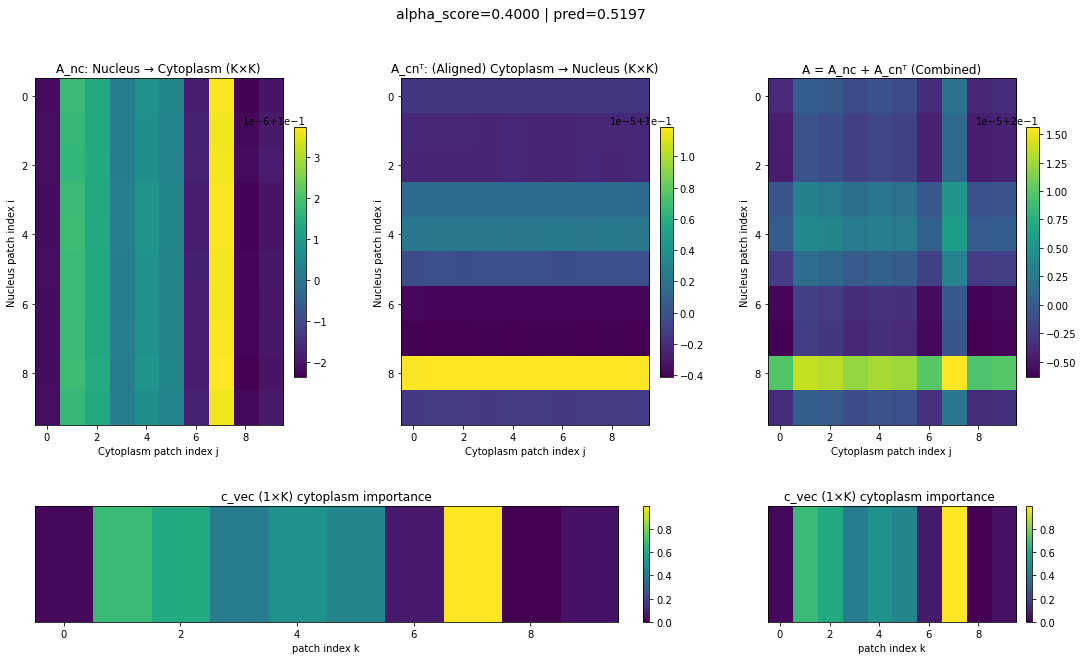

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy.ndimage

# Load the original image in grayscale
image_path = "/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/checking/stress/7_.jpg"
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise ValueError(f"Error: Unable to load image from {image_path}")


def visualize_cross_attention_and_vectors(batch, model, device, normalize_vectors=True):
    model.eval()

    nucleus_patches = batch["nucleus_patches"].to(device)
    non_nucleus_patches = batch["non_nucleus_patches"].to(device)

    with torch.no_grad():
        output, _, _, nc_weights, cn_weights, learned_alpha = model(nucleus_patches, non_nucleus_patches)

        pred = output.view(-1)[0].item()  # probability (B=first)
        A_nc = nc_weights[0].detach().cpu()        # (K,K)
        A_cn = cn_weights[0].detach().cpu()        # (K,K) (C,N)
        A_cn_aligned = A_cn.t()                    # (K,K) (N,C)

        # Combined interaction map
        A = A_nc + A_cn_aligned                    # (K,K)

        # Importance vectors
        n_vec = A.mean(dim=1)                      # (K,) nucleus importance (row-mean)
        c_vec = A.mean(dim=0)                      # (K,) cyto importance (col-mean)

        # alpha score = dot(n_vec, c_vec)
        alpha_score = torch.dot(n_vec, c_vec).item()

    # ---- optional: normalize vectors for display (NOT for alpha) ----
    n_disp = n_vec.clone()
    c_disp = c_vec.clone()
    if normalize_vectors:
        # min-max to [0,1] for easy color interpretation
        def minmax(x):
            return (x - x.min()) / (x.max() - x.min() + 1e-8)
        n_disp = minmax(n_disp)
        c_disp = minmax(c_disp)

    # ---- visualization ----
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], wspace=0.35, hspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(A_nc.numpy(), aspect="auto")
    ax0.set_title("A_nc: Nucleus → Cytoplasm (K×K)")
    ax0.set_xlabel("Cytoplasm patch index j")
    ax0.set_ylabel("Nucleus patch index i")
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(A_cn_aligned.numpy(), aspect="auto")
    ax1.set_title("A_cnᵀ: (Aligned) Cytoplasm → Nucleus (K×K)")
    ax1.set_xlabel("Cytoplasm patch index j")
    ax1.set_ylabel("Nucleus patch index i")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(gs[0, 2])
    im2 = ax2.imshow(A.numpy(), aspect="auto")
    ax2.set_title("A = A_nc + A_cnᵀ (Combined)")
    ax2.set_xlabel("Cytoplasm patch index j")
    ax2.set_ylabel("Nucleus patch index i")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # --- 1×K vector heatmaps (bars) ---
    ax3 = fig.add_subplot(gs[1, 0:2])
    im3 = ax3.imshow(c_disp.unsqueeze(0).numpy(), aspect="auto")
    ax3.set_title("c_vec (1×K) cytoplasm importance")
    ax3.set_xlabel("patch index k")
    ax3.set_yticks([])
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    ax4 = fig.add_subplot(gs[1, 2])
    im4 = ax4.imshow(c_disp.unsqueeze(0).numpy(), aspect="auto")
    ax4.set_title("c_vec (1×K) cytoplasm importance ")
    ax4.set_xlabel("patch index k")
    ax4.set_yticks([])
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

    fig.suptitle(f"alpha_score={alpha_score:.4f} | pred={pred:.4f}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return alpha_score, pred


# Run for one batch
for batch in image7_val_loader:
    if batch is None:
        continue
    alpha_score, pred = visualize_cross_attention_and_vectors(batch, cross_attention_model, device)
    #print("alpha_score:", alpha_score)
    #print("prediction :", pred)
    break


/tmp/ipykernel_2408494/118008340.py:46: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2408494/118008340.py:46: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2408494/118008340.py:61: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the co

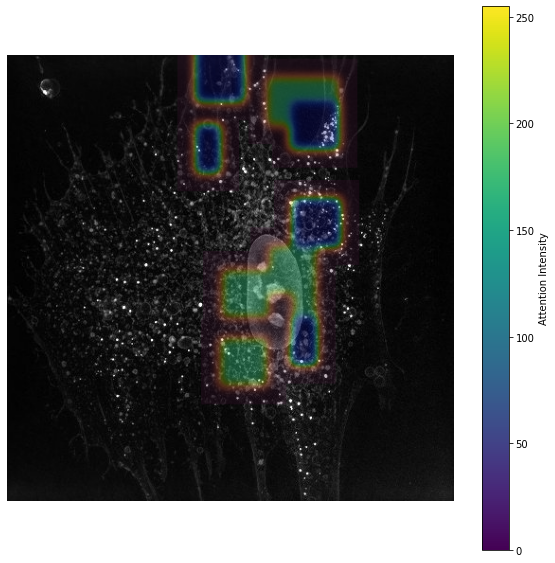

In [ ]:
# import torch
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# import scipy.ndimage

# # Load the original image in grayscale
# image_path = "/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/stress/193_RI.jpg"
# original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# if original_image is None:
#     raise ValueError(f"Error: Unable to load image from {image_path}")

# # ✅ Iterate through validation batch
# for batch in extra_val_loader:
#     nucleus_patches = batch["nucleus_patches"].to(device)  # (B, N, 1, H, W)
#     non_nucleus_patches = batch["non_nucleus_patches"].to(device)  # (B, M, 1, H, W)
#     nucleus_locations = batch["nucleus_locations"]  # List of (x_start, y_start, x_end, y_end)
#     non_nucleus_locations = batch["non_nucleus_locations"]  # List of (x, y)

#     # ✅ Get model outputs including attention weights
#     _, _, _, nc_weights, cn_weights, _ = cross_attention_model(nucleus_patches, non_nucleus_patches)

#     # ✅ Extract attention weights (impact on each other)
#     nc_weights = nc_weights.detach().cpu().numpy()  # (B, N, M) -> Impact of non-nucleus on nucleus
#     cn_weights = cn_weights.detach().cpu().numpy()  # (B, M, N) -> Impact of nucleus on non-nucleus

#     # ✅ Compute **importance scores**
#     nucleus_importance = nc_weights.mean(axis=-1)  # (B, N)
#     non_nucleus_importance = cn_weights.mean(axis=-1)  # (B, M)

#     # ✅ Normalize importance scores (avoid division errors)
#     nucleus_importance = (nucleus_importance - nucleus_importance.min()) / (nucleus_importance.max() - nucleus_importance.min() + 1e-8)
#     non_nucleus_importance = (non_nucleus_importance - non_nucleus_importance.min()) / (non_nucleus_importance.max() - non_nucleus_importance.min() + 1e-8)

#     # ✅ Create an empty overlay heatmap (same size as original image)
#     patch_overlay = np.zeros_like(original_image, dtype=np.float32)

#     # ✅ Overlay **nucleus importance scores** (Ensuring 50x50 patches)
#     H, W = original_image.shape[:2]

#     for i, loc in enumerate(nucleus_locations):
#         # loc can be tensor/list; make it 4 python ints
#         if torch.is_tensor(loc):
#             loc = loc.detach().cpu().numpy()
#         loc = np.array(loc).reshape(-1)

#         x_start = int(loc[0]); y_start = int(loc[1])
#         # you don't actually need loc[2], loc[3] — just force 50x50 from top-left
#         x_end = min(W, x_start + 50)
#         y_end = min(H, y_start + 50)

#         if (y_end - y_start == 50) and (x_end - x_start == 50):
#             patch_overlay[y_start:y_end, x_start:x_end] = nucleus_importance[0, i]

#     # ✅ Overlay **non-nucleus importance scores** (Ensuring 50x50 patches)
#     non_nucleus_patch_size = 50  # Ensure all non-nucleus patches are also 50x50
#     for i, loc in enumerate(non_nucleus_locations):
#         if torch.is_tensor(loc):
#             loc = loc.detach().cpu().numpy()
#         loc = np.array(loc).reshape(-1)

#         if len(loc) >= 4:
#             # if it is (x1,y1,x2,y2) -> use top-left
#             x_start = int(loc[0]); y_start = int(loc[1])
#         else:
#             # if it is (x,y) center
#             x = int(loc[0]); y = int(loc[1])
#             x_start = max(0, x - 25)
#             y_start = max(0, y - 25)

#         x_end = min(W, x_start + 50)
#         y_end = min(H, y_start + 50)

#         if (y_end - y_start == 50) and (x_end - x_start == 50):
#             patch_overlay[y_start:y_end, x_start:x_end] = non_nucleus_importance[0, i]

#     # ✅ Apply **Gaussian smoothing** to blend heatmap
#     patch_overlay = scipy.ndimage.gaussian_filter(patch_overlay, sigma=5)

#     # ✅ Normalize only the patches (not background)
#     mask = patch_overlay > 0  # Mask for valid patches
#     patch_overlay[mask] = (patch_overlay[mask] - patch_overlay[mask].min()) / (patch_overlay[mask].max() - patch_overlay[mask].min() + 1e-8)
#     patch_overlay = np.uint8(255 * patch_overlay)

#     # ✅ Apply **Red-to-Blue colormap**
#     heatmap_colored = cv2.applyColorMap(patch_overlay, cv2.COLORMAP_TURBO)  # Alternative: cv2.COLORMAP_TURBO

#     # ✅ Overlay heatmap only where patches exist
#     overlayed_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)
#     overlayed_image[mask] = cv2.addWeighted(overlayed_image, 0.7, heatmap_colored, 0.3, 0)[mask]

#     # ✅ Display result with color bar
#     plt.figure(figsize=(10, 10))
#     plt.imshow(overlayed_image)
#     plt.colorbar(label="Attention Intensity")
#     #plt.title("Smoothed Attention Weight Overlay (Red → Blue Gradient)")
#     plt.axis("off")
#     plt.show()
#     break


In [ ]:
# import torch
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# import scipy.ndimage


# def minmax_np(x, eps=1e-8):
#     return (x - x.min()) / (x.max() - x.min() + eps)


# def loc_to_box_50(loc, H, W):
#     if torch.is_tensor(loc):
#         loc = loc.detach().cpu().numpy()
#     loc = np.array(loc).reshape(-1)

#     if len(loc) >= 4:
#         x1, y1 = int(loc[0]), int(loc[1])
#     else:
#         x, y = int(loc[0]), int(loc[1])
#         x1, y1 = max(0, x - 25), max(0, y - 25)

#     x2, y2 = min(W, x1 + 50), min(H, y1 + 50)
#     if (x2 - x1 == 50) and (y2 - y1 == 50):
#         return x1, y1, x2, y2
#     return None


# def visualize_cross_attention_minimal(
#     batch,
#     model,
#     device,
#     image_path,
#     top_t=10,
#     alpha_use_normalized=True
# ):
#     model.eval()

#     # ---------------- image ----------------
#     original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#     if original_image is None:
#         raise ValueError(f"Cannot load image: {image_path}")
#     H, W = original_image.shape

#     nucleus_patches = batch["nucleus_patches"].to(device)
#     non_nucleus_patches = batch["non_nucleus_patches"].to(device)

#     nucleus_locations = batch["nucleus_locations"]
#     non_nucleus_locations = batch["non_nucleus_locations"]

#     with torch.no_grad():
#         output, _, _, nc_weights, cn_weights, _ = model(
#             nucleus_patches, non_nucleus_patches
#         )

#     pred = output.view(-1)[0].item()

#     # ---------------- cross attention ----------------
#     A_nc = nc_weights[0].detach().cpu()   # (K,K)
#     A_cn = cn_weights[0].detach().cpu()   # (K,K)
#     A_cnT = A_cn.t()
#     A = A_nc + A_cnT                      # ✅ MAIN MAP

#     # importance vectors (still computed)
#     n_vec = A.mean(dim=1)
#     c_vec = A.mean(dim=0)

#     # alpha score
#     if alpha_use_normalized:
#         n_for_alpha = (n_vec - n_vec.min()) / (n_vec.max() - n_vec.min() + 1e-8)
#         c_for_alpha = (c_vec - c_vec.min()) / (c_vec.max() - c_vec.min() + 1e-8)
#         alpha_score = torch.dot(n_for_alpha, c_for_alpha).item()
#     else:
#         alpha_score = torch.dot(n_vec, c_vec).item()

#     # ---------------- patch boxes ----------------
#     nuc_boxes, cyto_boxes = [], []

#     for i, loc in enumerate(nucleus_locations):
#         box = loc_to_box_50(loc, H, W)
#         if box is not None:
#             nuc_boxes.append((i, *box))

#     for i, loc in enumerate(non_nucleus_locations):
#         box = loc_to_box_50(loc, H, W)
#         if box is not None:
#             cyto_boxes.append((i, *box))

#     # rank & keep top patches
#     n_rank = torch.argsort(n_vec, descending=True).cpu().numpy()
#     c_rank = torch.argsort(c_vec, descending=True).cpu().numpy()

#     nuc_boxes = [b for b in nuc_boxes if b[0] in n_rank[:top_t]]
#     cyto_boxes = [b for b in cyto_boxes if b[0] in c_rank[:top_t]]

#     # ---------------- overlay heatmap ----------------
#     overlay = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)
#     patch_overlay = np.zeros((H, W), dtype=np.float32)
#     mask = np.zeros((H, W), dtype=np.uint8)

#     n_imp = minmax_np(n_vec.cpu().numpy())
#     c_imp = minmax_np(c_vec.cpu().numpy())

#     for i, x1, y1, x2, y2 in nuc_boxes:
#         patch_overlay[y1:y2, x1:x2] = n_imp[i]
#         mask[y1:y2, x1:x2] = 1

#     for i, x1, y1, x2, y2 in cyto_boxes:
#         patch_overlay[y1:y2, x1:x2] = c_imp[i]
#         mask[y1:y2, x1:x2] = 1

#     patch_overlay = scipy.ndimage.gaussian_filter(patch_overlay, sigma=5)
#     patch_overlay[mask > 0] = minmax_np(patch_overlay[mask > 0])

#     heat = cv2.applyColorMap(np.uint8(255 * patch_overlay), cv2.COLORMAP_TURBO)
#     overlay[mask > 0] = cv2.addWeighted(overlay, 0.7, heat, 0.3, 0)[mask > 0]

#     # numbered boxes
#     def draw_boxes(img, boxes, color, prefix):
#         for i, x1, y1, x2, y2 in boxes:
#             cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
#             cv2.putText(img, f"{prefix}{i+1}", (x1+2, y1-4),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.6,
#                         (255,255,255), 2)
#         return img

#     overlay = draw_boxes(overlay, nuc_boxes, (0,255,0), "N")
#     overlay = draw_boxes(overlay, cyto_boxes, (0,0,255), "C")

#     # ---------------- visualization ----------------
#     fig = plt.figure(figsize=(25, 10))
#     gs = fig.add_gridspec(1, 2, wspace=0.3)

#     # ---- Combined A map ONLY ----
#     ax0 = fig.add_subplot(gs[0])
#     im = ax0.imshow(A.numpy(), aspect="auto")
#     ax0.set_title("Interaction matrix")
#     #ax0.set_title("A = A_nc + A_cnᵀ (Combined Interaction)")
#     ax0.set_xlabel("Cytoplasm patch j")
#     ax0.set_ylabel("Nucleus patch i")

#     cbar = plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
#     cbar.formatter.set_scientific(False)
#     cbar.formatter.set_useOffset(False)
#     cbar.update_ticks()

#     # ---- Overlay image ----
#     ax1 = fig.add_subplot(gs[1])
#     ax1.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
#     ax1.set_title("Overlay + numbered patches (N=green, C=red)")
#     ax1.axis("off")

#     #fig.suptitle(f"alpha={alpha_score:.4f} | pred={pred:.4f}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

#     return alpha_score, pred


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt


def loc_to_box_50(loc, H, W):
    if torch.is_tensor(loc):
        loc = loc.detach().cpu().numpy()
    loc = np.array(loc).reshape(-1)

    if len(loc) >= 4:
        x1, y1 = int(loc[0]), int(loc[1])
    else:
        x, y = int(loc[0]), int(loc[1])
        x1, y1 = max(0, x - 25), max(0, y - 25)

    x2, y2 = min(W, x1 + 50), min(H, y1 + 50)
    if (x2 - x1 == 50) and (y2 - y1 == 50):
        return x1, y1, x2, y2
    return None


def visualize_cross_attention_minimal(
    batch,
    model,
    device,
    image_path,
    top_t=10,
    alpha_use_normalized=True
):
    model.eval()

    # ---------------- image ----------------
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original_image is None:
        raise ValueError(f"Cannot load image: {image_path}")
    H, W = original_image.shape

    nucleus_patches = batch["nucleus_patches"].to(device)
    non_nucleus_patches = batch["non_nucleus_patches"].to(device)

    nucleus_locations = batch["nucleus_locations"]
    non_nucleus_locations = batch["non_nucleus_locations"]

    with torch.no_grad():
        output, _, _, nc_weights, cn_weights, _ = model(nucleus_patches, non_nucleus_patches)

    pred = output.view(-1)[0].item()

    # ---------------- cross attention ----------------
    A_nc = nc_weights[0].detach().cpu()   # (K,K)
    A_cn = cn_weights[0].detach().cpu()   # (K,K)
    A_cnT = A_cn.t()
    A = A_nc + A_cnT                      # ✅ MAIN MAP

    # importance vectors (still computed)
    n_vec = A.mean(dim=1)
    c_vec = A.mean(dim=0)

    # alpha score (still computed but not used for coloring)
    if alpha_use_normalized:
        n_for_alpha = (n_vec - n_vec.min()) / (n_vec.max() - n_vec.min() + 1e-8)
        c_for_alpha = (c_vec - c_vec.min()) / (c_vec.max() - c_vec.min() + 1e-8)
        alpha_score = torch.dot(n_for_alpha, c_for_alpha).item()
    else:
        alpha_score = torch.dot(n_vec, c_vec).item()

    # ---------------- patch boxes ----------------
    nuc_boxes, cyto_boxes = [], []

    for i, loc in enumerate(nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            nuc_boxes.append((i, *box))

    for i, loc in enumerate(non_nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            cyto_boxes.append((i, *box))

    # rank & keep top patches (optional)
    n_rank = torch.argsort(n_vec, descending=True).cpu().numpy()
    c_rank = torch.argsort(c_vec, descending=True).cpu().numpy()
    nuc_boxes = [b for b in nuc_boxes if b[0] in n_rank[:top_t]]
    cyto_boxes = [b for b in cyto_boxes if b[0] in c_rank[:top_t]]

    # ---------------- PLAIN overlay (NO heatmap coloring) ----------------
    overlay = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)

    # numbered boxes (labels ABOVE the box, no background)
    def draw_boxes(img, boxes, color, prefix):
        for i, x1, y1, x2, y2 in boxes:
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            label = f"{prefix}{i+1}"
            y_text = max(15, y1 - 6)  # put text above box, clamp
            cv2.putText(
                img,
                label,
                (x1, y_text),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
                cv2.LINE_AA
            )
        return img

    overlay = draw_boxes(overlay, nuc_boxes, (0, 255, 0), "N")
    overlay = draw_boxes(overlay, cyto_boxes, (0, 0, 255), "C")

    # ---------------- visualization ----------------
    fig = plt.figure(figsize=(25, 10))
    gs = fig.add_gridspec(1, 2, wspace=0.3)

    ax0 = fig.add_subplot(gs[0])
    im = ax0.imshow(A.numpy(), aspect="auto")
    ax0.set_title("Interaction matrix")
    ax0.set_xlabel("Cytoplasm patch j")
    ax0.set_ylabel("Nucleus patch i")
    cbar = plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
    cbar.formatter.set_scientific(False)
    cbar.formatter.set_useOffset(False)
    cbar.update_ticks()

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax1.set_title("")
    ax1.axis("off")

    # legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor='none', edgecolor='green', linewidth=2, label='Nucleus patches'),
        Patch(facecolor='none', edgecolor='red', linewidth=2, label='Cytoplasm patches')
    ]

    ax1.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),  # ⬅ outside image
        frameon=False,
        fontsize=20
    )

    plt.tight_layout()
    plt.show()

    return alpha_score, pred


/tmp/ipykernel_2415640/3114822115.py:10: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3114822115.py:10: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3114822115.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so res

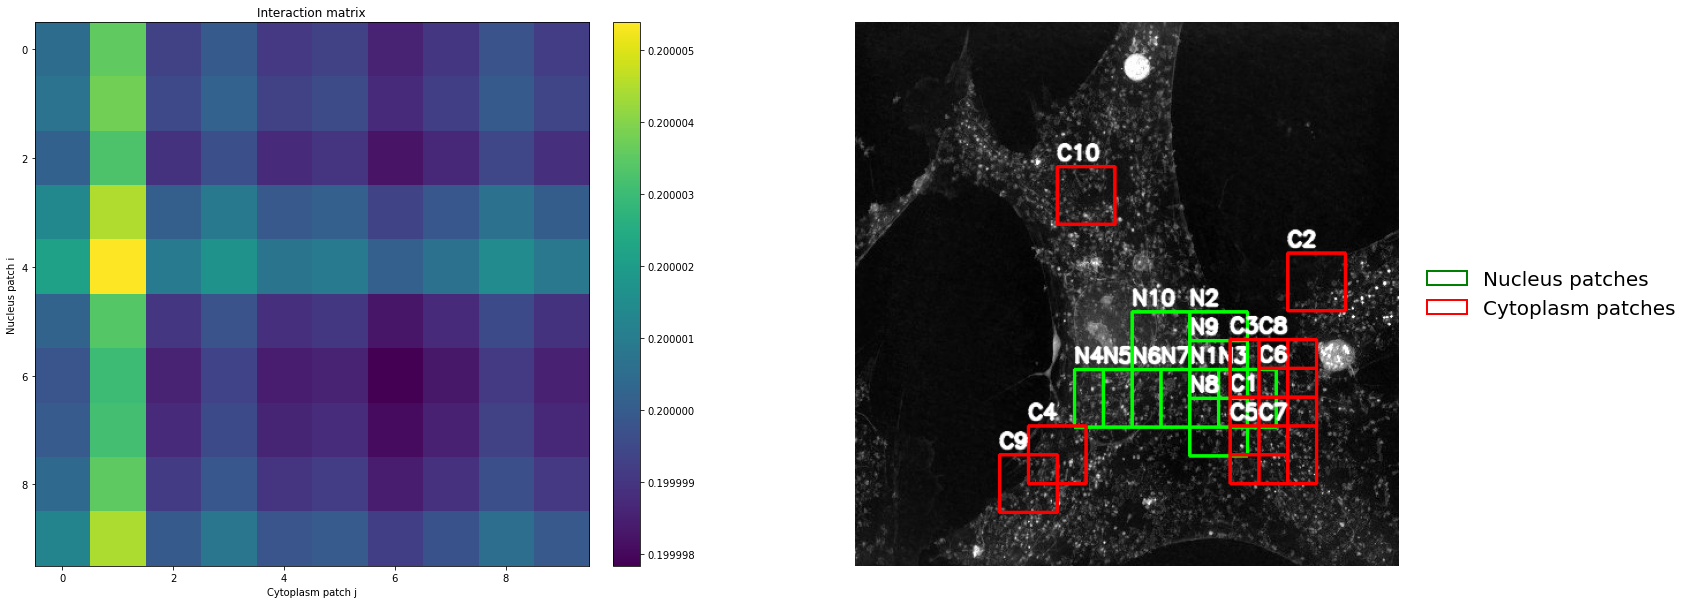

alpha_score: 0.9733604192733765


In [ ]:
for batch in extra_val_loader:
    if batch is None:
        continue
    alpha_score, pred = visualize_cross_attention_minimal(
        batch=batch,
        model=cross_attention_model,
        device=device,
        image_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/control/145_RI.jpg",
        top_t=10,                 # reduce to 5 if you want less clutter
        alpha_use_normalized=True
    )
    print("alpha_score:", alpha_score)
    #print("prediction :", pred)
    break


/tmp/ipykernel_2415640/3908032168.py:14: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3908032168.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3908032168.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so res

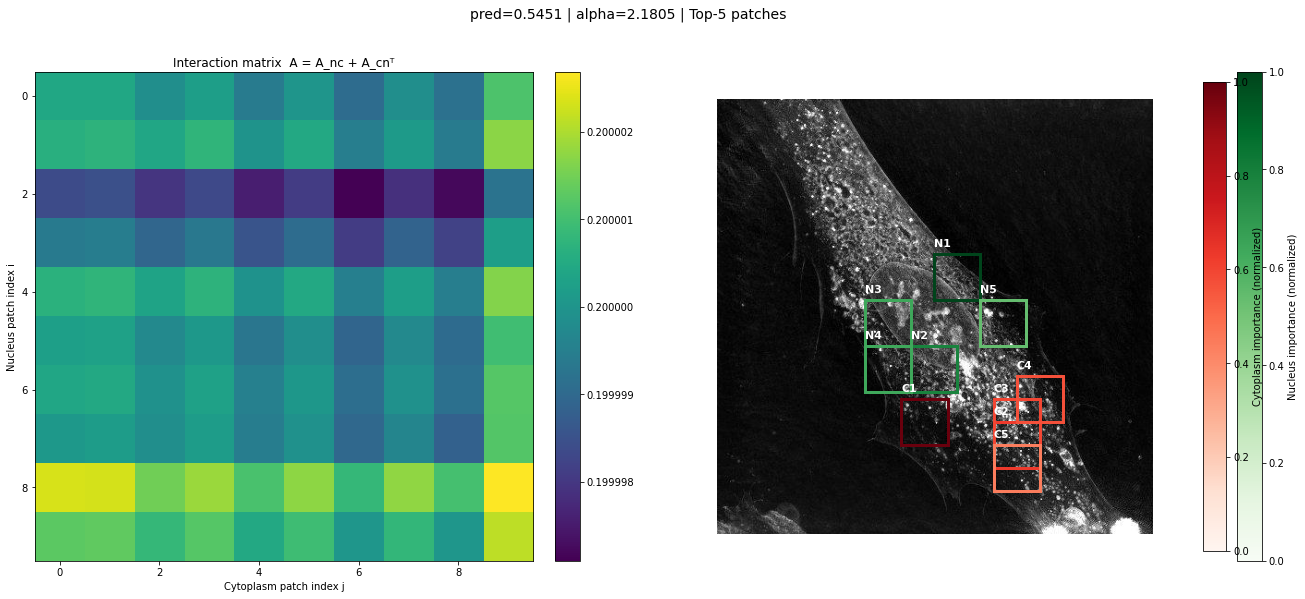

alpha_score: 2.18054461479187
prediction : 0.5450887680053711
Top nucleus idx: [8, 9, 4, 1, 6]
Top cyto idx  : [9, 1, 0, 3, 5]


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def loc_to_box_50(loc, H, W):
    """Convert nucleus/cyto loc to a 50x50 (x1,y1,x2,y2) box. Returns None if out-of-bounds."""
    if torch.is_tensor(loc):
        loc = loc.detach().cpu().numpy()
    loc = np.array(loc).reshape(-1)

    if len(loc) >= 4:
        x1, y1 = int(loc[0]), int(loc[1])  # treat as top-left
    else:
        x, y = int(loc[0]), int(loc[1])    # treat as center
        x1, y1 = max(0, x - 25), max(0, y - 25)

    x2 = min(W, x1 + 50)
    y2 = min(H, y1 + 50)
    if (x2 - x1 == 50) and (y2 - y1 == 50):
        return x1, y1, x2, y2
    return None


def minmax_torch(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)


def visualize_interaction_border_only_topk(
    batch,
    model,
    device,
    image_path,
    top_k=5,
    alpha_use_normalized=True,
    nucleus_cmap="Greens",
    cyto_cmap="Reds",
    border_lw=3,
    label_fontsize=11,
    label_offset=6
):
    """
    Left: Interaction matrix A = A_nc + A_cn^T
    Right: Original image + Top-K nucleus/cytoplasm boxes (border-only color intensity)
           - Green border intensity = nucleus importance (n_vec)
           - Red border intensity   = cytoplasm importance (c_vec)
           - Two colorbars (one per group)
    """
    model.eval()

    # --- load image ---
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")
    H, W = img.shape

    nucleus_patches = batch["nucleus_patches"].to(device)
    non_nucleus_patches = batch["non_nucleus_patches"].to(device)
    nucleus_locations = batch["nucleus_locations"]
    non_nucleus_locations = batch["non_nucleus_locations"]

    with torch.no_grad():
        output, _, _, nc_weights, cn_weights, _ = model(nucleus_patches, non_nucleus_patches)

    pred = float(output.view(-1)[0].item())

    # --- interaction matrix ---
    A_nc = nc_weights[0].detach().cpu()         # (N,C) = (K,K)
    A_cn = cn_weights[0].detach().cpu()         # (C,N) = (K,K)
    A = A_nc + A_cn.t()                         # (N,C) aligned and combined

    # --- importance vectors ---
    n_vec = A.mean(dim=1)                       # (K,)
    c_vec = A.mean(dim=0)                       # (K,)

    # alpha score (optional computation, not shown unless you want it)
    if alpha_use_normalized:
        n_for_alpha = minmax_torch(n_vec)
        c_for_alpha = minmax_torch(c_vec)
        alpha_score = float(torch.dot(n_for_alpha, c_for_alpha).item())
    else:
        alpha_score = float(torch.dot(n_vec, c_vec).item())

    # --- pick Top-K indices ---
    n_top_idx = torch.argsort(n_vec, descending=True)[:top_k].cpu().numpy().tolist()
    c_top_idx = torch.argsort(c_vec, descending=True)[:top_k].cpu().numpy().tolist()

    # normalize for color intensity (display only)
    n_disp = minmax_torch(n_vec).cpu().numpy()
    c_disp = minmax_torch(c_vec).cpu().numpy()

    # --- build boxes dict by index (so i maps to its box) ---
    nuc_boxes = {}
    for i, loc in enumerate(nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            nuc_boxes[i] = box

    cyto_boxes = {}
    for i, loc in enumerate(non_nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            cyto_boxes[i] = box

    # --- plot ---
    fig = plt.figure(figsize=(22, 9))
    gs = fig.add_gridspec(1, 2, wspace=0.25)

    # LEFT: A matrix
    ax0 = fig.add_subplot(gs[0, 0])
    imA = ax0.imshow(A.numpy(), aspect="auto")
    ax0.set_title("Interaction matrix  A = A_nc + A_cnᵀ")
    ax0.set_xlabel("Cytoplasm patch index j")
    ax0.set_ylabel("Nucleus patch index i")
    cbarA = plt.colorbar(imA, ax=ax0, fraction=0.046, pad=0.04)
    # remove scientific offset text like "1e-6 + ..."
    cbarA.formatter.set_scientific(False)
    cbarA.formatter.set_useOffset(False)
    cbarA.update_ticks()

    # RIGHT: border-only boxes
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(img, cmap="gray")
    ax1.set_title("")  # keep clean
    ax1.axis("off")

    nuc_cmap = plt.get_cmap(nucleus_cmap)
    cyto_cmap = plt.get_cmap(cyto_cmap)

    # Draw nucleus (Top-K)
    for rank, i in enumerate(n_top_idx, start=1):
        if i not in nuc_boxes:
            continue
        x1, y1, x2, y2 = nuc_boxes[i]
        col = nuc_cmap(n_disp[i])  # intensity-coded border
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=col, linewidth=border_lw)
        ax1.add_patch(rect)
        # label ABOVE the box (no background)
        ax1.text(
            x1, max(0, y1 - label_offset),
            f"N{rank}",
            color="white",
            fontsize=label_fontsize,
            weight="bold",
            va="bottom",
            ha="left"
        )

    # Draw cytoplasm (Top-K)
    for rank, i in enumerate(c_top_idx, start=1):
        if i not in cyto_boxes:
            continue
        x1, y1, x2, y2 = cyto_boxes[i]
        col = cyto_cmap(c_disp[i])
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=col, linewidth=border_lw)
        ax1.add_patch(rect)
        ax1.text(
            x1, max(0, y1 - label_offset),
            f"C{rank}",
            color="white",
            fontsize=label_fontsize,
            weight="bold",
            va="bottom",
            ha="left"
        )

    # --- two separate colorbars (nucleus + cytoplasm) ---
    # These indicate how the border intensity maps to importance (0..1 after minmax).
    sm_n = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=nuc_cmap)
    sm_n.set_array([])
    sm_c = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cyto_cmap)
    sm_c.set_array([])

    # Put them beside the overlay axis (stacked)
    cbarN = plt.colorbar(sm_n, ax=ax1, fraction=0.046, pad=0.02)
    cbarN.set_label("Nucleus importance (normalized)", rotation=90)

    cbarC = plt.colorbar(sm_c, ax=ax1, fraction=0.046, pad=0.10)
    cbarC.set_label("Cytoplasm importance (normalized)", rotation=90)

    # optional: show these in title if you want, otherwise comment out
    fig.suptitle(f"pred={pred:.4f} | alpha={alpha_score:.4f} | Top-{top_k} patches", fontsize=14)

    plt.tight_layout()
    plt.show()

    return alpha_score, pred, n_top_idx, c_top_idx


# Example usage (one batch)
for batch in extra_val_loader:
    if batch is None:
        continue
    alpha_score, pred, n_top_idx, c_top_idx = visualize_interaction_border_only_topk(
        batch=batch,
        model=cross_attention_model,
        device=device,
        image_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/stress/7_.jpg",
        top_k=5,                 # ✅ Top-5 only
        alpha_use_normalized=True
    )
    print("alpha_score:", alpha_score)
    print("prediction :", pred)
    print("Top nucleus idx:", n_top_idx)
    print("Top cyto idx  :", c_top_idx)
    break


/tmp/ipykernel_2415640/3625595822.py:13: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3625595822.py:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3625595822.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so res

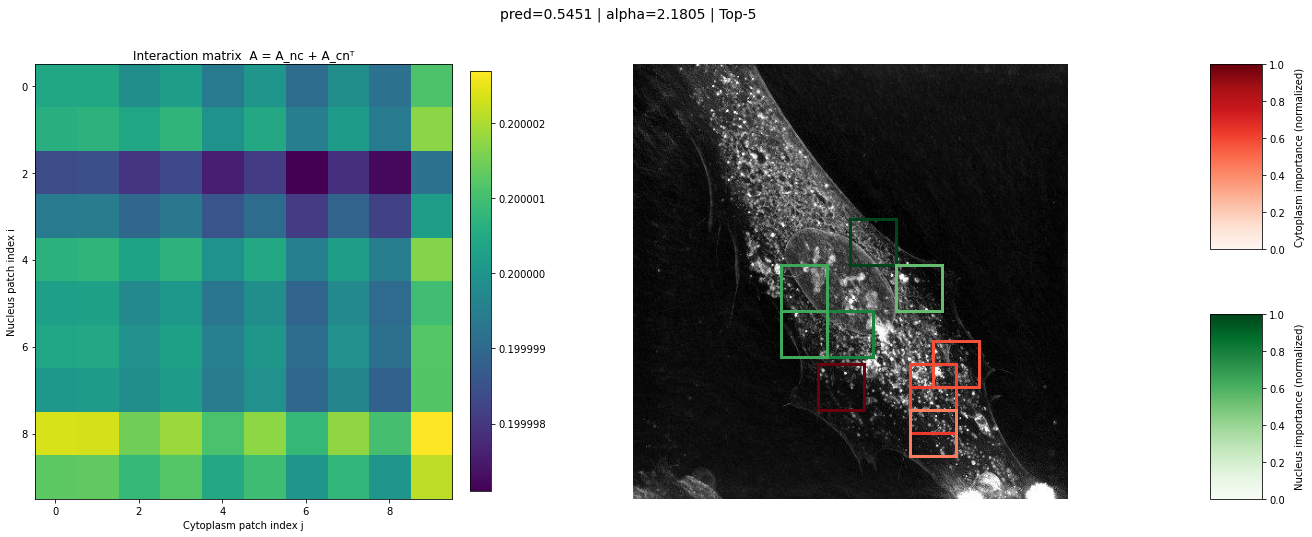

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def loc_to_box_50(loc, H, W):
    if torch.is_tensor(loc):
        loc = loc.detach().cpu().numpy()
    loc = np.array(loc).reshape(-1)

    if len(loc) >= 4:
        x1, y1 = int(loc[0]), int(loc[1])
    else:
        x, y = int(loc[0]), int(loc[1])
        x1, y1 = max(0, x - 25), max(0, y - 25)

    x2, y2 = min(W, x1 + 50), min(H, y1 + 50)
    if (x2 - x1 == 50) and (y2 - y1 == 50):
        return x1, y1, x2, y2
    return None


def minmax_torch(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)


def visualize_interaction_border_only_topk(
    batch,
    model,
    device,
    image_path,
    top_k=5,
    alpha_use_normalized=True,
    nucleus_cmap="Greens",
    cyto_cmap="Reds",
    border_lw=3,
    label_fontsize=11,
    label_offset=6
):
    model.eval()

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")
    H, W = img.shape

    nucleus_patches = batch["nucleus_patches"].to(device)
    non_nucleus_patches = batch["non_nucleus_patches"].to(device)
    nucleus_locations = batch["nucleus_locations"]
    non_nucleus_locations = batch["non_nucleus_locations"]

    with torch.no_grad():
        output, _, _, nc_weights, cn_weights, _ = model(nucleus_patches, non_nucleus_patches)

    pred = float(output.view(-1)[0].item())

    # Interaction matrix A
    A_nc = nc_weights[0].detach().cpu()
    A_cn = cn_weights[0].detach().cpu()
    A = A_nc + A_cn.t()

    # Importance vectors
    n_vec = A.mean(dim=1)
    c_vec = A.mean(dim=0)

    # Alpha score
    if alpha_use_normalized:
        n_for_alpha = minmax_torch(n_vec)
        c_for_alpha = minmax_torch(c_vec)
        alpha_score = float(torch.dot(n_for_alpha, c_for_alpha).item())
    else:
        alpha_score = float(torch.dot(n_vec, c_vec).item())

    # Top-K indices
    n_top_idx = torch.argsort(n_vec, descending=True)[:top_k].cpu().numpy().tolist()
    c_top_idx = torch.argsort(c_vec, descending=True)[:top_k].cpu().numpy().tolist()

    # Display intensity (0..1)
    n_disp = minmax_torch(n_vec).cpu().numpy()
    c_disp = minmax_torch(c_vec).cpu().numpy()

    # Boxes by index
    nuc_boxes = {}
    for i, loc in enumerate(nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            nuc_boxes[i] = box

    cyto_boxes = {}
    for i, loc in enumerate(non_nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            cyto_boxes[i] = box

    # --- plotting layout: [A matrix | image | colorbars] ---
    fig = plt.figure(figsize=(22, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.25, 0.12], wspace=0.25)

    # LEFT: A matrix
    axA = fig.add_subplot(gs[0, 0])
    imA = axA.imshow(A.numpy(), aspect="auto")
    axA.set_title("Interaction matrix  A = A_nc + A_cnᵀ")
    axA.set_xlabel("Cytoplasm patch index j")
    axA.set_ylabel("Nucleus patch index i")
    cbarA = fig.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
    cbarA.formatter.set_scientific(False)
    cbarA.formatter.set_useOffset(False)
    cbarA.update_ticks()

    # MIDDLE: image + border-only boxes
    axI = fig.add_subplot(gs[0, 1])
    axI.imshow(img, cmap="gray")
    axI.axis("off")

    nuc_cmap = plt.get_cmap(nucleus_cmap)
    cyto_cmap = plt.get_cmap(cyto_cmap)

    # Nucleus boxes (Top-K)
    for rank, i in enumerate(n_top_idx, start=1):
        if i not in nuc_boxes:
            continue
        x1, y1, x2, y2 = nuc_boxes[i]
        col = nuc_cmap(n_disp[i])
        axI.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=col, linewidth=border_lw))
        # axI.text(x1, max(0, y1 - label_offset), f"N{rank}",
        #          color="white", fontsize=label_fontsize, weight="bold",
        #          va="bottom", ha="left")

    # Cytoplasm boxes (Top-K)
    for rank, i in enumerate(c_top_idx, start=1):
        if i not in cyto_boxes:
            continue
        x1, y1, x2, y2 = cyto_boxes[i]
        col = cyto_cmap(c_disp[i])
        axI.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=col, linewidth=border_lw))
        # axI.text(x1, max(0, y1 - label_offset), f"C{rank}",
        #          color="white", fontsize=label_fontsize, weight="bold",
        #          va="bottom", ha="left")

    # RIGHT: two stacked colorbars in a dedicated column
    cgs = gs[0, 2].subgridspec(2, 1, hspace=0.35)  # stacked
    axCbarC = fig.add_subplot(cgs[0, 0])  # cytoplasm bar axis
    axCbarN = fig.add_subplot(cgs[1, 0])  # nucleus bar axis

    # Make scalar mappables (0..1)
    sm_c = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cyto_cmap)
    sm_c.set_array([])
    sm_n = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=nuc_cmap)
    sm_n.set_array([])

    cbC = fig.colorbar(sm_c, cax=axCbarC)
    cbC.set_label("Cytoplasm importance (normalized)", rotation=90, labelpad=10)

    cbN = fig.colorbar(sm_n, cax=axCbarN)
    cbN.set_label("Nucleus importance (normalized)", rotation=90, labelpad=10)

    fig.suptitle(f"pred={pred:.4f} | alpha={alpha_score:.4f} | Top-{top_k}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return alpha_score, pred, n_top_idx, c_top_idx
for batch in extra_val_loader:
    if batch is None:
        continue
    alpha_score, pred, n_top, c_top = visualize_interaction_border_only_topk(
        batch=batch,
        model=cross_attention_model,
        device=device,
        image_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/stress/7_.jpg",
        top_k=5
    )
    break


/tmp/ipykernel_2415640/3481236681.py:15: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_2415640/3481236681.py:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)


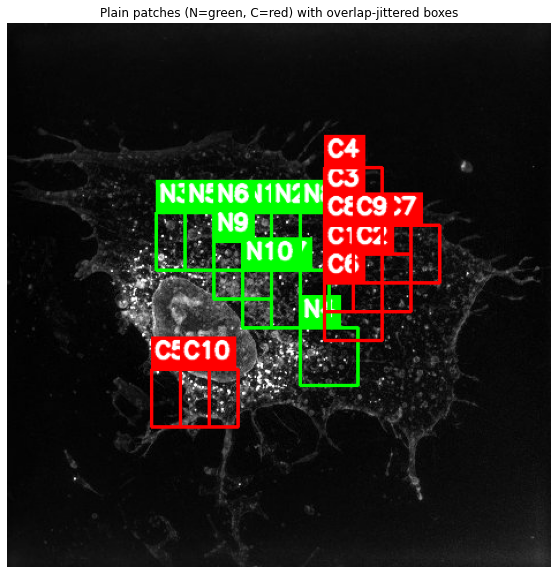

In [ ]:
# import torch
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt


# def loc_to_box_50(loc, H, W):
#     """
#     Convert a location (tensor/list/np) into a fixed 50x50 box.
#     - If loc has >=4 values: treat as (x1,y1,x2,y2) and use (x1,y1) as top-left.
#     - Else: treat as (x,y) center and convert to top-left.
#     """
#     if torch.is_tensor(loc):
#         loc = loc.detach().cpu().numpy()
#     loc = np.array(loc).reshape(-1)

#     if len(loc) >= 4:
#         x1, y1 = int(loc[0]), int(loc[1])
#     else:
#         x, y = int(loc[0]), int(loc[1])
#         x1, y1 = max(0, x - 25), max(0, y - 25)

#     x2 = min(W, x1 + 50)
#     y2 = min(H, y1 + 50)

#     if (x2 - x1 == 50) and (y2 - y1 == 50):
#         return x1, y1, x2, y2
#     return None


# def apply_overlap_jitter(boxes, H, W, max_jitter=10, step=2):
#     """
#     If multiple boxes share the same top-left (x1,y1), offset them slightly
#     so their edges are visible.
#     We keep size fixed 50x50 and clamp inside image boundaries.
#     """
#     # group by top-left
#     from collections import defaultdict
#     groups = defaultdict(list)
#     for item in boxes:
#         idx, x1, y1, x2, y2 = item
#         groups[(x1, y1)].append(item)

#     out = []
#     for (x1, y1), grp in groups.items():
#         if len(grp) == 1:
#             out.append(grp[0])
#             continue

#         # create small offsets: 0, +step, -step, +2step, -2step, ...
#         offsets = [0]
#         for t in range(1, (len(grp) // 2) + 3):
#             offsets.append(+t * step)
#             offsets.append(-t * step)

#         # apply to y-direction first (looks more natural), then x-direction if needed
#         for g_i, item in enumerate(grp):
#             idx, bx1, by1, bx2, by2 = item
#             off = offsets[g_i]
#             new_y1 = by1 + off
#             new_x1 = bx1

#             # if too many, start shifting in x also
#             if abs(off) > max_jitter:
#                 # wrap some into x shift
#                 xoff = (off // step) * step
#                 new_x1 = bx1 + xoff
#                 new_y1 = by1

#             # clamp top-left so 50x50 stays inside
#             new_x1 = int(np.clip(new_x1, 0, W - 50))
#             new_y1 = int(np.clip(new_y1, 0, H - 50))
#             out.append((idx, new_x1, new_y1, new_x1 + 50, new_y1 + 50))

#     return out


# def draw_plain_boxes_numbered(image_path, batch, top_t=None, jitter_overlaps=True):
#     """
#     Plain overlay: nucleus + cytoplasm boxes with numbering.
#     - top_t: show only first top_t patches (if you want less clutter). If None, show all.
#     - jitter_overlaps: apply small shifts to overlapping boxes to make boundaries visible.
#     """
#     original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#     if original is None:
#         raise ValueError(f"Error: Unable to load image from {image_path}")
#     H, W = original.shape[:2]
#     overlay = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)

#     nucleus_locations = batch["nucleus_locations"]
#     non_nucleus_locations = batch["non_nucleus_locations"]

#     # build boxes
#     nuc_boxes = []
#     for i, loc in enumerate(nucleus_locations):
#         box = loc_to_box_50(loc, H, W)
#         if box is None:
#             continue
#         x1, y1, x2, y2 = box
#         nuc_boxes.append((i, x1, y1, x2, y2))

#     cyto_boxes = []
#     for i, loc in enumerate(non_nucleus_locations):
#         box = loc_to_box_50(loc, H, W)
#         if box is None:
#             continue
#         x1, y1, x2, y2 = box
#         cyto_boxes.append((i, x1, y1, x2, y2))

#     # optionally reduce clutter
#     if top_t is not None:
#         nuc_boxes = nuc_boxes[:top_t]
#         cyto_boxes = cyto_boxes[:top_t]

#     # jitter overlaps (separately for nucleus and cyto so colors remain consistent)
#     if jitter_overlaps:
#         nuc_boxes = apply_overlap_jitter(nuc_boxes, H, W, max_jitter=10, step=2)
#         cyto_boxes = apply_overlap_jitter(cyto_boxes, H, W, max_jitter=10, step=2)

#     def draw_boxes(img, boxes, color_bgr, prefix):
#         H, W = img.shape[:2]

#         for (i, x1, y1, x2, y2) in boxes:
#             cv2.rectangle(img, (x1, y1), (x2, y2), color_bgr, 2)

#             label = f"{prefix}{i+1}"
#             font = cv2.FONT_HERSHEY_SIMPLEX
#             font_scale = 0.65
#             thickness = 2

#             (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)

#             # --- prefer ABOVE the box ---
#             pad = 3
#             top_y = y1 - (th + baseline + 2 * pad)

#             if top_y >= 0:
#                 # place label above
#                 bx1 = x1
#                 by1 = top_y
#                 bx2 = min(W, x1 + tw + 2 * pad)
#                 by2 = y1
#                 text_org = (x1 + pad, y1 - baseline - pad)
#             else:
#                 # fallback: place label BELOW the box
#                 bx1 = x1
#                 by1 = y2
#                 bx2 = min(W, x1 + tw + 2 * pad)
#                 by2 = min(H, y2 + th + baseline + 2 * pad)
#                 text_org = (x1 + pad, y2 + th + pad)

#             # background rectangle
#             cv2.rectangle(img, (bx1, by1), (bx2, by2), color_bgr, -1)

#             # white text on top
#             cv2.putText(img, label, text_org, font, font_scale, (255, 255, 255),
#                         thickness, cv2.LINE_AA)

#         return img


#     # N green, C red
#     overlay = draw_boxes(overlay, nuc_boxes, (0, 255, 0), "N")
#     overlay = draw_boxes(overlay, cyto_boxes, (0, 0, 255), "C")

#     plt.figure(figsize=(10, 10))
#     plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.title("Plain patches (N=green, C=red) with overlap-jittered boxes")
#     plt.show()

#     return overlay


# # ---------- RUN (first batch only) ----------
# for batch in extra_val_loader:
#     if batch is None:
#         continue
#     draw_plain_boxes_numbered(
#         image_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/stress/183_RI.jpg",
#         batch=batch,
#         top_t=10,              # set None to show all
#         jitter_overlaps=True   # important for overlap visibility
#     )
#     break


In [ ]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def loc_to_box_50(loc, H, W):
    if torch.is_tensor(loc):
        loc = loc.detach().cpu().numpy()
    loc = np.array(loc).reshape(-1)

    if len(loc) >= 4:
        x1, y1 = int(loc[0]), int(loc[1])
    else:
        x, y = int(loc[0]), int(loc[1])
        x1, y1 = max(0, x - 25), max(0, y - 25)

    x2, y2 = min(W, x1 + 50), min(H, y1 + 50)
    if (x2 - x1 == 50) and (y2 - y1 == 50):
        return x1, y1, x2, y2
    return None


def minmax_torch(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)


def _save_standalone_colorbar(
    out_path,
    cmap_name,
    label=None,
    orientation="vertical",
    dpi=300,
    transparent=True,
    remove_ticks=True
):
    import matplotlib as mpl
    fig = plt.figure(figsize=(0.8, 3.5) if orientation == "vertical" else (3.5, 0.8), dpi=dpi)

    # axis placement to fill canvas nicely
    if orientation == "vertical":
        cax = fig.add_axes([0.35, 0.02, 0.3, 0.96])  # left,bottom,width,height
    else:
        cax = fig.add_axes([0.02, 0.35, 0.96, 0.3])

    cmap = mpl.cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cb = fig.colorbar(sm, cax=cax, orientation=orientation)

    if label is not None and label != "":
        cb.set_label(label, rotation=90 if orientation == "vertical" else 0, labelpad=10)

    if remove_ticks:
        cb.set_ticks([])
        cb.ax.tick_params(length=0)

    # Optional: remove border around the bar (clean for PPT)
    # cb.outline.set_visible(False)

    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", pad_inches=0, transparent=transparent)
    plt.close(fig)


def visualize_interaction_border_only_topk(
    batch,
    model,
    device,
    image_path,
    top_k=5,
    alpha_use_normalized=True,
    nucleus_cmap="Greens",
    cyto_cmap="Reds",
    border_lw=3,
    label_fontsize=11,
    label_offset=6,
    # ---- NEW: saving ----
    save=False,
    save_dir="./exports",
    base_name="sample",
    dpi=300,
    save_colorbars_without_ticks=True
):
    model.eval()

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")
    H, W = img.shape

    nucleus_patches = batch["nucleus_patches"].to(device)
    non_nucleus_patches = batch["non_nucleus_patches"].to(device)
    nucleus_locations = batch["nucleus_locations"]
    non_nucleus_locations = batch["non_nucleus_locations"]

    with torch.no_grad():
        output, _, _, nc_weights, cn_weights, _ = model(nucleus_patches, non_nucleus_patches)

    pred = float(output.view(-1)[0].item())

    # Interaction matrix A
    A_nc = nc_weights[0].detach().cpu()
    A_cn = cn_weights[0].detach().cpu()
    A = A_nc + A_cn.t()

    # Importance vectors
    n_vec = A.mean(dim=1)
    c_vec = A.mean(dim=0)

    # Alpha score
    if alpha_use_normalized:
        n_for_alpha = minmax_torch(n_vec)
        c_for_alpha = minmax_torch(c_vec)
        alpha_score = float(torch.dot(n_for_alpha, c_for_alpha).item())
    else:
        alpha_score = float(torch.dot(n_vec, c_vec).item())

    # Top-K indices
    n_top_idx = torch.argsort(n_vec, descending=True)[:top_k].cpu().numpy().tolist()
    c_top_idx = torch.argsort(c_vec, descending=True)[:top_k].cpu().numpy().tolist()

    # Display intensity (0..1)
    n_disp = minmax_torch(n_vec).cpu().numpy()
    c_disp = minmax_torch(c_vec).cpu().numpy()

    # Boxes by index
    nuc_boxes = {}
    for i, loc in enumerate(nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            nuc_boxes[i] = box

    cyto_boxes = {}
    for i, loc in enumerate(non_nucleus_locations):
        box = loc_to_box_50(loc, H, W)
        if box is not None:
            cyto_boxes[i] = box

    # --- plotting layout: [A matrix | image | colorbars] ---
    fig = plt.figure(figsize=(22, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.25, 0.12], wspace=0.25)

    # LEFT: A matrix
    axA = fig.add_subplot(gs[0, 0])
    imA = axA.imshow(A.numpy(), aspect="auto")
    axA.set_title("Interaction matrix  A = A_nc + A_cnᵀ")
    axA.set_xlabel("Cytoplasm patch index j")
    axA.set_ylabel("Nucleus patch index i")
    cbarA = fig.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
    cbarA.formatter.set_scientific(False)
    cbarA.formatter.set_useOffset(False)
    cbarA.update_ticks()

    # MIDDLE: image + border-only boxes
    axI = fig.add_subplot(gs[0, 1])
    axI.imshow(img, cmap="gray")
    axI.axis("off")

    nuc_cmap = plt.get_cmap(nucleus_cmap)
    cyto_cmap = plt.get_cmap(cyto_cmap)

    # Nucleus boxes (Top-K)
    for rank, i in enumerate(n_top_idx, start=1):
        if i not in nuc_boxes:
            continue
        x1, y1, x2, y2 = nuc_boxes[i]
        col = nuc_cmap(n_disp[i])
        axI.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=col, linewidth=border_lw))
        # ---- PATCH NUMBERING (comment/uncomment these 2 lines) ----
        # axI.text(x1, max(0, y1 - label_offset), f"N{rank}",
        #          color="white", fontsize=label_fontsize, weight="bold",
        #          va="bottom", ha="left")

    # Cytoplasm boxes (Top-K)
    for rank, i in enumerate(c_top_idx, start=1):
        if i not in cyto_boxes:
            continue
        x1, y1, x2, y2 = cyto_boxes[i]
        col = cyto_cmap(c_disp[i])
        axI.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=col, linewidth=border_lw))
        # ---- PATCH NUMBERING (comment/uncomment these 2 lines) ----
        # axI.text(x1, max(0, y1 - label_offset), f"C{rank}",
        #          color="white", fontsize=label_fontsize, weight="bold",
        #          va="bottom", ha="left")

    # RIGHT: two stacked colorbars in a dedicated column (for display)
    cgs = gs[0, 2].subgridspec(2, 1, hspace=0.35)
    axCbarC = fig.add_subplot(cgs[0, 0])
    axCbarN = fig.add_subplot(cgs[1, 0])

    sm_c = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cyto_cmap)
    sm_c.set_array([])
    sm_n = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=nuc_cmap)
    sm_n.set_array([])

    cbC = fig.colorbar(sm_c, cax=axCbarC)
    cbC.set_label("Cytoplasm importance (normalized)", rotation=90, labelpad=10)

    cbN = fig.colorbar(sm_n, cax=axCbarN)
    cbN.set_label("Nucleus importance (normalized)", rotation=90, labelpad=10)

    fig.suptitle(f"pred={pred:.4f} | alpha={alpha_score:.4f} | Top-{top_k}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # NEW: SAVE SEPARATE FILES
    # -------------------------
    if save:
        os.makedirs(save_dir, exist_ok=True)

        # (1) Save A-matrix only (axis + cbar)
        figA = plt.figure(figsize=(6, 5), dpi=dpi)
        ax = figA.add_subplot(111)
        im = ax.imshow(A.numpy(), aspect="auto")
        ax.set_title("Interaction matrix")
        ax.set_xlabel("Cytoplasm j")
        ax.set_ylabel("Nucleus i")
        cb = figA.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.formatter.set_scientific(False)
        cb.formatter.set_useOffset(False)
        cb.update_ticks()
        pathA = os.path.join(save_dir, f"{base_name}_A_matrix.png")
        figA.savefig(pathA, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
        plt.close(figA)

        # (2) Save overlay only (no margins)
        figO = plt.figure(figsize=(6, 6), dpi=dpi)
        axo = figO.add_axes([0, 0, 1, 1])
        axo.imshow(img, cmap="gray")
        axo.axis("off")
        # redraw the same rectangles (overlay-only export)
        for rank, i in enumerate(n_top_idx, start=1):
            if i in nuc_boxes:
                x1,y1,x2,y2 = nuc_boxes[i]
                col = nuc_cmap(n_disp[i])
                axo.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=col, linewidth=border_lw))
                # numbering (optional)
                # axo.text(x1, max(0, y1 - label_offset), f"N{rank}", color="white",
                #          fontsize=label_fontsize, weight="bold", va="bottom", ha="left")
        for rank, i in enumerate(c_top_idx, start=1):
            if i in cyto_boxes:
                x1,y1,x2,y2 = cyto_boxes[i]
                col = cyto_cmap(c_disp[i])
                axo.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=col, linewidth=border_lw))
                # numbering (optional)
                # axo.text(x1, max(0, y1 - label_offset), f"C{rank}", color="white",
                #          fontsize=label_fontsize, weight="bold", va="bottom", ha="left")

        pathO = os.path.join(save_dir, f"{base_name}_overlay.png")
        figO.savefig(pathO, dpi=dpi, bbox_inches="tight", pad_inches=0, transparent=False)
        plt.close(figO)

        # (3) Save colorbars as separate PNGs (NO tick values)
        pathC = os.path.join(save_dir, f"{base_name}_cyto_colorbar.png")
        pathN = os.path.join(save_dir, f"{base_name}_nuc_colorbar.png")

        _save_standalone_colorbar(
            out_path=pathC,
            cmap_name=cyto_cmap.name,  # use actual cmap name
            remove_ticks=save_colorbars_without_ticks,
            dpi=dpi,
            transparent=True
        )
        _save_standalone_colorbar(
            out_path=pathN,
            cmap_name=nuc_cmap.name,
            remove_ticks=save_colorbars_without_ticks,
            dpi=dpi,
            transparent=True
        )

        print("Saved:")
        print("A-matrix :", pathA)
        print("Overlay  :", pathO)
        print("Cyto bar :", pathC)
        print("Nuc  bar :", pathN)

    return alpha_score, pred, n_top_idx, c_top_idx


/tmp/ipykernel_880097/2116578882.py:14: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_880097/2116578882.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  loc = np.array(loc).reshape(-1)
/tmp/ipykernel_880097/2116578882.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so result

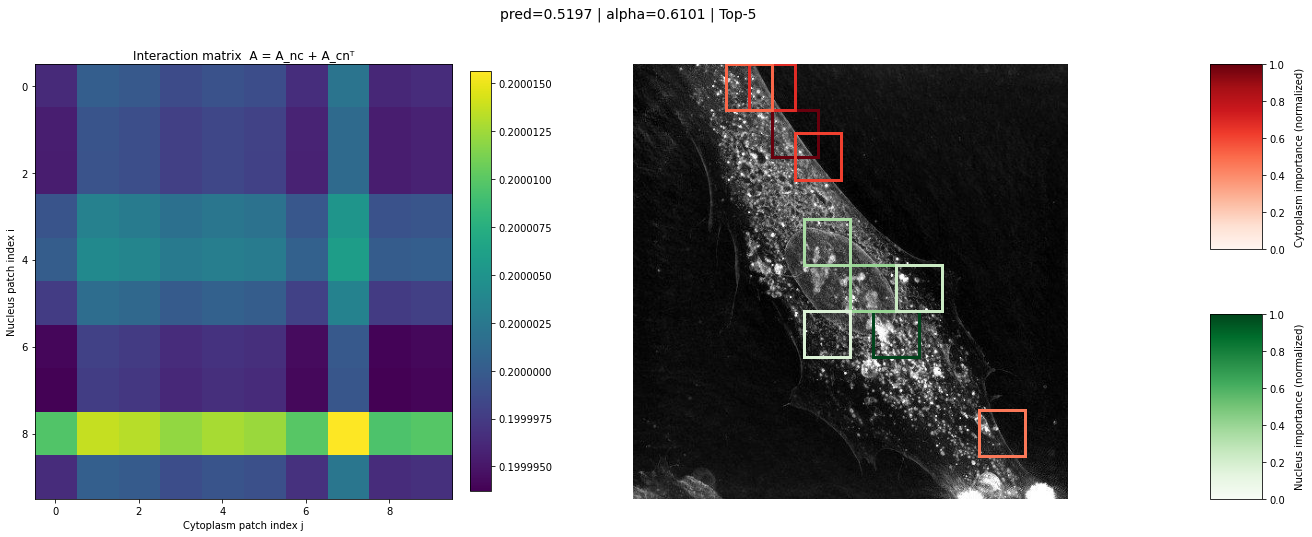

Saved:
A-matrix : /home/yaganapu/senescence/fig_exports/stress_7_top5_A_matrix.png
Overlay  : /home/yaganapu/senescence/fig_exports/stress_7_top5_overlay.png
Cyto bar : /home/yaganapu/senescence/fig_exports/stress_7_top5_cyto_colorbar.png
Nuc  bar : /home/yaganapu/senescence/fig_exports/stress_7_top5_nuc_colorbar.png


/tmp/ipykernel_880097/2116578882.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


In [ ]:
for batch in image7_val_loader:
    if batch is None:
        continue
    alpha_score, pred, n_top, c_top = visualize_interaction_border_only_topk(
        batch=batch,
        model=cross_attention_model,
        device=device,
        image_path="/home/yaganapu/senescence/data_jan22_compelteforpaper1/checking_visualizations/checking/stress/7_.jpg",
        top_k=5,
        save=True,
        save_dir="/home/yaganapu/senescence/fig_exports/",
        base_name="stress_7_top5",
        dpi=300
    )
    break
